# The face and gaze direction during the Renaissance

## Overview

We investigated the orientation of faces in portrait paintings from the Renaissance period (14th to late 16th century) to understand artistic trends in subject depiction. Using OpenFace (version 2.2.0), we analyzed 1,017 portraits from the Web Gallery of Art (as of December 2024). Among these, 871 faces were successfully processed, including those from multi-figure compositions (which were then left out of the analysis). The results revealed a bimodal distribution of facial orientations, symmetrically balanced to the left and right of the frontal axis. Focusing on faces turned to the right from a frontal view, we calculated the mean rotation angle to be approximately 23° from the frontal position. We detail the results below.


## Set-up

In [1]:
# Load required R libraries.
# loading library and setting up directory
suppressWarnings(suppressMessages(library(tidyverse)))
suppressWarnings(suppressMessages(library(lmerTest)))
suppressWarnings(suppressMessages(library(ggeffects)))
suppressWarnings(suppressMessages(library(emmeans)))
suppressWarnings(suppressMessages(library(sjPlot)))
suppressWarnings(suppressMessages(library(magrittr)))
suppressWarnings(suppressMessages(library(DescTools)))
suppressWarnings(suppressMessages(library(nnet)))# multinom()
suppressWarnings(suppressMessages(library(broom)))# tidy() for model summaries
suppressWarnings(suppressMessages(library(broom.mixed)))# tidy() for model summaries
suppressWarnings(suppressMessages(library(performance)))  # for ICC
suppressWarnings(suppressMessages(library(sjstats)))      # alternative ICC calculation
suppressWarnings(suppressMessages(library(pbkrtest)))

# Set theme
apa_theme <- theme(
plot.margin = unit(c(1, 1, 1, 1), "cm"),
plot.background = element_rect(fill = "white", color = NA),
plot.title = element_text(size = 22, face = "bold",
                          hjust = 0.5,
                          margin = margin(b = 15)),
axis.line = element_line(color = "black", size = .5),
axis.title = element_text(size = 18, color = "black",
                          face = "bold"),
axis.text = element_text(size = 15, color = "black"),
axis.text.x = element_text(margin = margin(t = 10)),
axis.title.y = element_text(margin = margin(r = 10)),
axis.ticks = element_line(size = .5),
panel.grid = element_blank(),
legend.position = 'top',
legend.background = element_rect(color = "black"),
legend.text = element_text(size = 15),
legend.margin = margin(t = 5, l = 5, r = 5, b = 5),
legend.key = element_rect(color = NA, fill = NA)
)

theme_set(theme_minimal(base_size = 18) +
        apa_theme)


Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


In [2]:
# Read main dataset from CSV and inspect date range.

metadf <- read.csv('wiki_name_hits_title_majority.csv')
glimpse(metadf)
max(as.numeric(metadf$date),na.rm=T)

Rows: 2,569
Columns: 53
$ filename                 <chr> "00portr1", "0149burg", "01altovi", "01amerba…
$ Condition                <chr> "Renaissance", "Renaissance", "Renaissance", …
$ headYaw                  <dbl> 60.103273, 21.829692, -26.184171, 35.580679, …
$ headPitch                <dbl> 36.497412, 13.349917, 21.944284, 18.162762, 3…
$ gazeYaw                  <dbl> -40.1643414, -15.8709309, 13.2353251, -28.246…
$ gazePitch                <dbl> 32.88778, 18.16276, 24.40800, 23.60586, 31.85…
$ confidence               <dbl> 0.875, 0.975, 0.975, 0.875, 0.925, 0.975, 0.9…
$ emotion_index            <int> 0, 0, 5, 6, 7, 0, 0, 6, 0, 0, 0, 6, 5, 0, 2, …
$ gaze_yaw                 <dbl> -0.19717234, -0.07796484, -0.13617858, -0.148…
$ gaze_pitch               <dbl> 0.153603986, 0.229188904, 0.126954943, 0.1081…
$ AU1                      <dbl> 0.009657921, 0.132391378, 0.013894403, 0.0020…
$ AU2                      <dbl> 0.002877212, 0.041622251, 0.006624049, 0.0000…
$ AU3           

[1] 1923

In [3]:
# Filter portraits to confidence > 0.80, add time-frame variable, summarise sample size by condition.
metadf %>% filter(confidence > .80) -> metadf
metadf %>% mutate(TF=substring(TIMEFRAME,1,4)) -> metadf

# number of portraits in each condition
metadf %>% group_by(Condition) %>% summarise(n=n())
# levels(factor(metadf$SCHOOL))
metadf %>% mutate(SCHOOL = factor(SCHOOL,levels=c('Italian',
    'American','Austrian','Belgian','Bohemian','Danish',
    'Dutch','English','Finnish','Flemish','French','German',
    'Hungarian','Irish','Netherlandish','Norwegian',
    'Polish','Russian','Scottish','Spanish','Swedish','Swiss','Other'))) -> metadf

metadf %>% filter(Condition=='Renaissance',SCHOOL!='Other') %>% group_by(SCHOOL) %>% summarise(n=n()) %>% filter(n > 1)
metadf %>% filter(Condition=='Renaissance',SCHOOL!='Other') %>% group_by(SCHOOL) %>% summarise(n=n()) %>% filter(n > 1) %>% summarise(n=sum(n))


Condition,n
<chr>,<int>
Post_Renaissance,1339
Religion,162
Renaissance,968


SCHOOL,n
<fct>,<int>
Italian,456
Austrian,2
Dutch,16
English,27
Flemish,179
French,38
German,197
Netherlandish,5
Spanish,43


n
<int>
965


## Study 1: Gaze during the Renaissance

### Looker facing from right to center only (Renaissance) 

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: gazeYaw ~ sdate + (1 | SCHOOL) + (1 | AUTHOR)
   Data: .

REML criterion at convergence: 3844.4

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.8683 -0.5310 -0.0041  0.6779  2.3400 

Random effects:
 Groups   Name        Variance Std.Dev.
 AUTHOR   (Intercept) 31.698   5.630   
 SCHOOL   (Intercept)  1.635   1.279   
 Residual             51.684   7.189   
Number of obs: 546, groups:  AUTHOR, 140; SCHOOL, 11

Fixed effects:
             Estimate Std. Error        df t value Pr(>|t|)    
(Intercept) -15.73853    0.89572   5.42920 -17.571 5.41e-06 ***
sdate         0.06148    0.01488 144.25507   4.132 6.08e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
      (Intr)
sdate -0.041

,x,predicted,std.error,conf.low,conf.high,group,date
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>
1,-120,-23.11658,2.0304794,-27.10517,-19.127987,1,1411.027
2,-80,-20.65723,1.5189849,-23.64106,-17.673397,1,1451.027
3,-40,-18.19788,1.0956596,-20.35015,-16.045611,1,1491.027
4,0,-15.73853,0.8957181,-17.49804,-13.979018,1,1531.027
5,40,-13.27918,1.0549116,-15.35141,-11.206956,1,1571.027
6,80,-10.81983,1.4601549,-13.68810,-7.951564,1,1611.027
NA,NA,NA,NA,NA,NA,NA,NA


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_ribbon()`).”


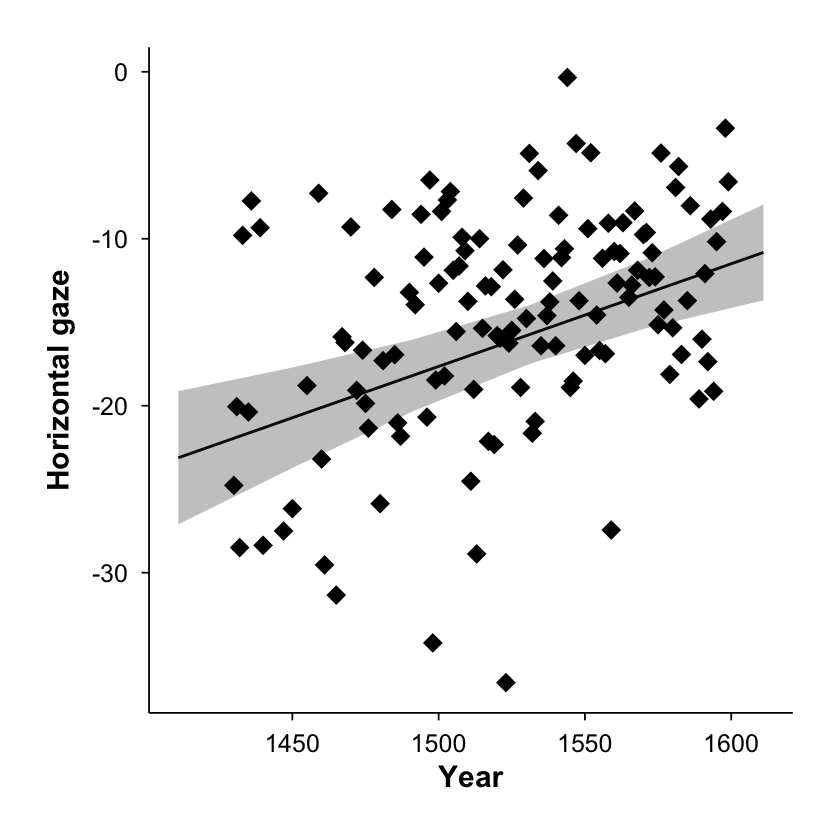

In [4]:
# Fit linear mixed model for rightward-gazing (gazeYaw < 0) Renaissance portraits predicting gaze angle from year; plot predicted trend.

metadf_renai <- metadf %>% filter(Condition=='Renaissance', SCHOOL != 'Other' & SCHOOL != 'Finnish' & SCHOOL != 'Norwegian', date >= 1400, date <= 1600,gazeYaw<0,headPitch<90,headPitch>-90)
metadf_renai %<>% mutate(sdate = scale(date,center=T,scale=F))
metadf_renai %>% lmer(gazeYaw~sdate+(1|SCHOOL)+(1 |AUTHOR),data=.,REML = TRUE) -> fit2
fit2 %>% summary()
glm_p <- ggpredict(fit2, terms = "sdate [-120:100 by=40]")
(glm_p %<>% mutate(date=mean(metadf_renai$date,na.rm=T)+x))

(p <-ggplot() + 
     geom_line(data = glm_p, aes(x = date, y = predicted), show.legend = F) + 
     geom_ribbon(data = glm_p, aes(x = date, ymin = conf.low, ymax = conf.high), alpha = 0.3,show.legend = F) +
     stat_summary(data = filter(metadf,Condition=='Renaissance', SCHOOL != 'Other' | SCHOOL != 'Finnish' | SCHOOL != 'Norwegian',date>1400,date<1600,gazeYaw<0,headPitch<90,headPitch>-90), aes(x = date, y = gazeYaw), fun= mean, geom="point", size = 5, shape = 18, position = position_dodge(width = .75)) +
     ylab('Horizontal gaze') + xlab('Year') + scale_x_continuous(breaks=seq(1400,1650,50)))
# ggsave('Gaze_Shift_Right_Renai_only.png',p)

In [5]:
# Extract fixed-effects coefficients and 95% CIs from the rightward-gaze model.
# Method A: Using lmerTest summary (includes df & p automatically)
fixed_summary <- summary(fit2)$coefficients
print(fixed_summary)
# Output will include: Estimate, Std. Error, df, t value, Pr(>|t|)

# Get 95% CIs for fixed effects
ci_fixed <- confint(fit2, 
                    level = 0.95,
                    method = "Wald")  # faster than "profile"
print(ci_fixed)

# Option B: Calculate from unstandardized coefficients
# β_std = β × (SD_predictor / SD_outcome)
beta_unstd <- summary(fit2)$coefficients[2, 1]
sd_year <- sd(metadf_renai$sdate, na.rm = TRUE)
sd_gaze <- sd(metadf_renai$gazeYaw, na.rm = TRUE)
beta_std_calc <- beta_unstd * (sd_year / sd_gaze)
 
print(paste("Standardized β (calculated):", round(beta_std_calc, 3)))

                Estimate Std. Error         df    t value     Pr(>|t|)
(Intercept) -15.73853005 0.89571814   5.429201 -17.570851 5.409750e-06
sdate         0.06148372 0.01488168 144.255074   4.131503 6.080729e-05
                   2.5 %       97.5 %
.sig01                NA           NA
.sig02                NA           NA
.sigma                NA           NA
(Intercept) -17.49410535 -13.98295474
sdate         0.03231616   0.09065129
[1] "Standardized β (calculated): 0.263"


In [6]:
# Extract random-effects variance components (school, artist, residual) from the rightward-gaze model.
# Get variance components
var_components <- VarCorr(fit2)

# Extract and format
# BUG FIX: AUTHOR and SCHOOL were swapped — "School" row now correctly reads $SCHOOL, "Artist" reads $AUTHOR
random_effects_table <- data.frame(
  Group = c("School", "Artist", "Residual"),
  Variance = c(
    as.numeric(var_components$SCHOOL[1, 1]),
    as.numeric(var_components$AUTHOR[1, 1]),
    attr(var_components, "sc")^2  # residual variance
  )
) %>%
  mutate(SD = sqrt(Variance))

print(random_effects_table)


     Group  Variance       SD
1   School  1.634905 1.278634
2   Artist 31.698049 5.630102
3 Residual 51.684031 7.189161


In [7]:
# Compile full results table combining fixed effects and CIs for the rightward-gaze model.
# ==========================================
# COMPREHENSIVE RESULTS COMPILATION
# ==========================================

# 1. FIXED EFFECTS TABLE
fixed_table <- summary(fit2)$coefficients %>%
  as.data.frame() %>%
  rownames_to_column("Predictor") %>%
  # Add confidence intervals
  cbind(
    CI_lower = confint(fit2, method = "Wald")[4:5, 1],
    CI_upper = confint(fit2, method = "Wald")[4:5, 2]
  ) %>%
  select(Predictor, Estimate, `Std. Error`, df, `t value`, `Pr(>|t|)`, 
         CI_lower, CI_upper) %>%
  rename(
    "Predictor" = Predictor,
    "β" = Estimate,
    "SE" = `Std. Error`,
    "df" = df,
    "t" = `t value`,
    "p" = `Pr(>|t|)`,
    "95% CI Lower" = CI_lower,
    "95% CI Upper" = CI_upper
  ) %>%
  mutate(
    "95% CI" = paste("[", round(`95% CI Lower`, 3), ", ", 
                     round(`95% CI Upper`, 3), "]", sep = ""),
    β = round(β, 3),
    SE = round(SE, 3),
    t = round(t, 2),
    p = ifelse(p < 0.001, "<.001", round(p, 3))
  ) %>%
  select(Predictor, β, SE, `95% CI`, t, df, p)
# Add standardized betas
fixed_table$`β_std` <- c(NA, round(beta_std_calc, 3))

print(fixed_table)

# 2. RANDOM EFFECTS TABLE
random_table <- data.frame(
  Group = c("School", "Artist", "Residual"),
  # BUG FIX: AUTHOR and SCHOOL were swapped — now School→$SCHOOL, Artist→$AUTHOR
  Variance = c(
    as.numeric(var_components$SCHOOL[1, 1]),
    as.numeric(var_components$AUTHOR[1, 1]),
    attr(var_components, "sc")^2
  ),
  SD = c(
    sqrt(as.numeric(var_components$SCHOOL[1, 1])),
    sqrt(as.numeric(var_components$AUTHOR[1, 1])),
    sqrt(attr(var_components, "sc")^2)
  )
) %>%
  mutate(
    Variance = round(Variance, 2),
    SD = round(SD, 2)
  )

print(random_table)

# # 3. MODEL STATISTICS
# model_stats <- data.frame(
#   Statistic = c(
#     "N observations",
#     "N schools",
#     "N artists",
#     "Log-likelihood",
#     "AIC",
#     "BIC",
#     "DF method"
#   ),
#   Value = c(
#     nobs(lmm_renaissance),
#     length(unique(renaissance_data$school)),
#     length(unique(renaissance_data$artist)),
#     round(logLik(lmm_renaissance)[1], 1),
#     round(AIC(lmm_renaissance), 1),
#     round(BIC(lmm_renaissance), 1),
#     "Satterthwaite"
#   )
# )

# print(model_stats)


              Predictor       β    SE             95% CI      t         df
(Intercept) (Intercept) -15.739 0.896 [-17.494, -13.983] -17.57   5.429201
sdate             sdate   0.061 0.015     [0.032, 0.091]   4.13 144.255074
                p β_std
(Intercept) <.001    NA
sdate       <.001 0.263
     Group Variance   SD
1   School     1.63 1.28
2   Artist    31.70 5.63
3 Residual    51.68 7.19


In [8]:
# Print fixed and random effects as formatted LaTeX tables for the rightward-gaze model.
library(knitr)
library(kableExtra)
library(xtable)

# # Combined table for publication
# kable(fixed_table, 
#       format = "html",
#       digits = 3,
#       caption = "Table 1. Fixed Effects Estimates") %>%
#   kable_styling(bootstrap_options = "striped")

# kable(random_table,
#       format = "html", 
#       digits = 3,
#       caption = "Table 2. Random Effects Variance Components") %>%
#   kable_styling(bootstrap_options = "striped")

# Generate LaTeX tables
print(xtable(fixed_table, 
             caption = "Fixed Effects Estimates",
             label = "tab:fixed_effects"),
      include.rownames = FALSE,
      booktabs = TRUE,
      file = "fixed_effects.tex")

print(xtable(random_table, 
             caption = "Random Effects Variance Components",
             label = "tab:random_effects"),
      include.rownames = FALSE,
      booktabs = TRUE,
      file = "random_effects.tex")




Attaching package: ‘kableExtra’


The following object is masked from ‘package:dplyr’:

    group_rows



Attaching package: ‘xtable’


The following object is masked from ‘package:performance’:

    display




### From left to center gaze (Renaissance)


boundary (singular) fit: see help('isSingular')



Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: gazeYaw ~ sdate + (1 | SCHOOL) + (1 | AUTHOR)
   Data: .

REML criterion at convergence: 2387.8

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.3256 -0.5730 -0.0631  0.6147  3.7294 

Random effects:
 Groups   Name        Variance Std.Dev.
 AUTHOR   (Intercept) 25.82    5.082   
 SCHOOL   (Intercept)  0.00    0.000   
 Residual             65.77    8.110   
Number of obs: 330, groups:  AUTHOR, 96; SCHOOL, 8

Fixed effects:
             Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)  14.58336    0.76829  75.25953  18.982   <2e-16 ***
sdate        -0.03418    0.01776 124.28693  -1.924   0.0566 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
      (Intr)
sdate 0.026 
optimizer (nloptwrap) convergence code: 0 (OK)
boundary (singular) fit: see help('isSingular')


,x,predicted,std.error,conf.low,conf.high,group,date
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>
1,-120,18.68483,2.2468619,14.264604,23.10506,1,1411.027
2,-80,17.31767,1.5978169,14.174305,20.46104,1,1451.027
3,-40,15.95052,1.0329469,13.918409,17.98262,1,1491.027
4,0,14.58336,0.7682907,13.071905,16.09481,1,1531.027
5,40,13.21620,1.0596661,11.131526,15.30087,1,1571.027
6,80,11.84904,1.6324351,8.637564,15.06051,1,1611.027
NA,NA,NA,NA,NA,NA,NA,NA


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_ribbon()`).”


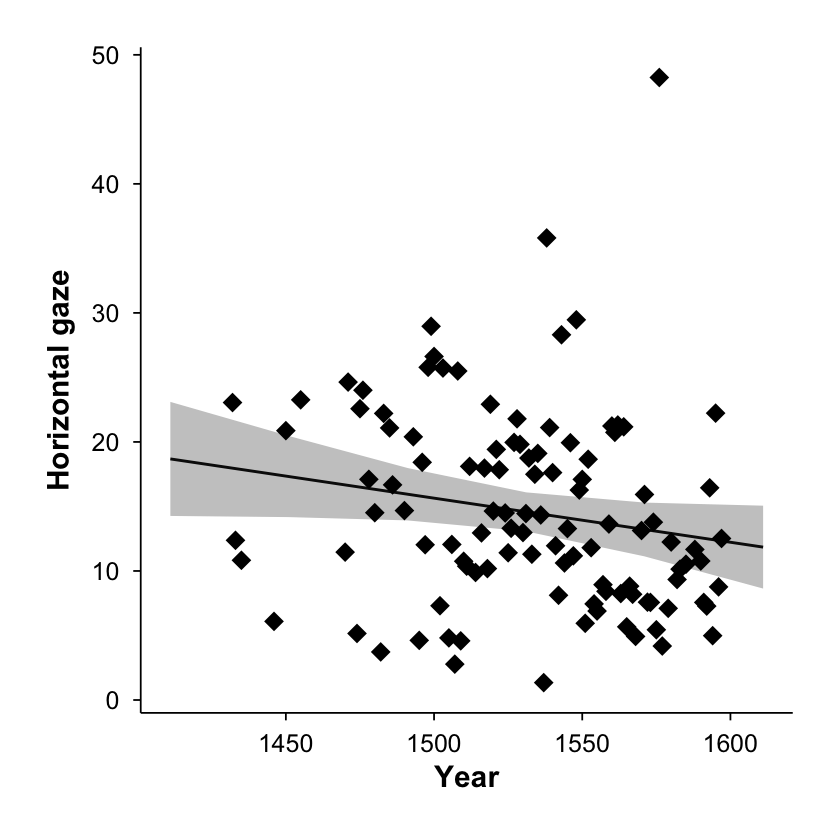

In [9]:
# Fit linear mixed model for leftward-gazing (gazeYaw >= 0) Renaissance portraits predicting gaze angle from year; plot predicted trend.

metadf_renai_left <- metadf %>% filter(Condition=='Renaissance', # BUG FIX: | (OR) changed to & (AND) — OR makes the condition always TRUE
  SCHOOL != 'Other' & SCHOOL != 'Finnish' & SCHOOL != 'Norwegian', date >= 1400, date <= 1600,gazeYaw>=0,headPitch<90,headPitch>-90)
metadf_renai_left %<>% mutate(sdate = scale(date,center=T,scale=F))
metadf_renai_left %>% lmer(gazeYaw~sdate+(1|SCHOOL)+(1 |AUTHOR),data=.) -> fit2
fit2 %>% summary()
glm_p <- ggpredict(fit2, terms = "sdate [-120:100 by=40]")
(glm_p %<>% mutate(date=mean(metadf_renai$date,na.rm=T)+x))

(p <-ggplot() + 
     geom_line(data = glm_p, aes(x = date, y = predicted), show.legend = F) + 
     geom_ribbon(data = glm_p, aes(x = date, ymin = conf.low, ymax = conf.high), alpha = 0.3,show.legend = F) +
     stat_summary(data = filter(metadf,Condition=='Renaissance', SCHOOL != 'Other' & SCHOOL != 'Finnish' & SCHOOL != 'Norwegian',date>1400,date<1600,gazeYaw>=0,headPitch<90,headPitch>-90), aes(x = date, y = gazeYaw), fun= mean, geom="point", size = 5, shape = 18, position = position_dodge(width = .75)) +
     ylab('Horizontal gaze') + xlab('Year') + scale_x_continuous(breaks=seq(1400,1650,50)))
# ggsave('Gaze_Shift_Left_Renai_only.png',p)

In [10]:
# Extract fixed-effects coefficients and 95% CIs from the leftward-gaze model.
# Method A: Using lmerTest summary (includes df & p automatically)
fixed_summary <- summary(fit2)$coefficients
print(fixed_summary)
# Output will include: Estimate, Std. Error, df, t value, Pr(>|t|)

# Get 95% CIs for fixed effects
ci_fixed <- confint(fit2, 
                    level = 0.95,
                    method = "Wald")  # faster than "profile"
print(ci_fixed)

# Option B: Calculate from unstandardized coefficients
# β_std = β × (SD_predictor / SD_outcome)
beta_unstd <- summary(fit2)$coefficients[2, 1]
sd_year <- sd(metadf_renai$sdate, na.rm = TRUE)
sd_gaze <- sd(metadf_renai$gazeYaw, na.rm = TRUE)
beta_std_calc <- beta_unstd * (sd_year / sd_gaze)
 
print(paste("Standardized β (calculated):", round(beta_std_calc, 3)))

# Get variance components
var_components <- VarCorr(fit2)

# Extract and format
random_effects_table <- data.frame(
  Group = c("School", "Artist", "Residual"),
  Variance = c(
    as.numeric(var_components$AUTHOR[1, 1]),
    as.numeric(var_components$SCHOOL[1, 1]),
    attr(var_components, "sc")^2  # residual variance
  )
) %>%
  mutate(SD = sqrt(Variance))

print(random_effects_table)

# ==========================================
# COMPREHENSIVE RESULTS COMPILATION
# ==========================================

# 1. FIXED EFFECTS TABLE
fixed_table <- summary(fit2)$coefficients %>%
  as.data.frame() %>%
  rownames_to_column("Predictor") %>%
  # Add confidence intervals
  cbind(
    CI_lower = confint(fit2, method = "Wald")[4:5, 1],
    CI_upper = confint(fit2, method = "Wald")[4:5, 2]
  ) %>%
  select(Predictor, Estimate, `Std. Error`, df, `t value`, `Pr(>|t|)`, 
         CI_lower, CI_upper) %>%
  rename(
    "Predictor" = Predictor,
    "β" = Estimate,
    "SE" = `Std. Error`,
    "df" = df,
    "t" = `t value`,
    "p" = `Pr(>|t|)`,
    "95% CI Lower" = CI_lower,
    "95% CI Upper" = CI_upper
  ) %>%
  mutate(
    "95% CI" = paste("[", round(`95% CI Lower`, 3), ", ", 
                     round(`95% CI Upper`, 3), "]", sep = ""),
    β = round(β, 3),
    SE = round(SE, 3),
    t = round(t, 2),
    p = ifelse(p < 0.001, "<.001", round(p, 3))
  ) %>%
  select(Predictor, β, SE, `95% CI`, t, df, p)
# Add standardized betas
fixed_table$`β_std` <- c(NA, round(beta_std_calc, 3))

print(fixed_table)

# 2. RANDOM EFFECTS TABLE
random_table <- data.frame(
  Group = c("School", "Artist", "Residual"),
  Variance = c(
    as.numeric(var_components$AUTHOR[1, 1]),
    as.numeric(var_components$SCHOOL[1, 1]),
    attr(var_components, "sc")^2
  ),
  SD = c(
    sqrt(as.numeric(var_components$AUTHOR[1, 1])),
    sqrt(as.numeric(var_components$SCHOOL[1, 1])),
    sqrt(attr(var_components, "sc")^2)
  )
) %>%
  mutate(
    Variance = round(Variance, 2),
    SD = round(SD, 2)
  )

print(random_table)

# Generate LaTeX tables
print(xtable(fixed_table, 
             caption = "Fixed Effects Estimates",
             label = "tab:fixed_effects"),
      include.rownames = FALSE,
      booktabs = TRUE,
      file = "result2_fixed_effects.tex")

print(xtable(random_table, 
             caption = "Random Effects Variance Components",
             label = "tab:random_effects"),
      include.rownames = FALSE,
      booktabs = TRUE,
      file = "result2_random_effects.tex")




               Estimate Std. Error        df   t value     Pr(>|t|)
(Intercept) 14.58335594 0.76829067  75.25953 18.981561 2.042144e-30
sdate       -0.03417898 0.01775995 124.28693 -1.924498 5.657786e-02
                  2.5 %       97.5 %
.sig01               NA           NA
.sig02               NA           NA
.sigma               NA           NA
(Intercept) 13.07753390 1.608918e+01
sdate       -0.06898784 6.298798e-04
[1] "Standardized β (calculated): -0.146"
     Group Variance       SD
1   School 25.82378 5.081710
2   Artist  0.00000 0.000000
3 Residual 65.76787 8.109739
              Predictor      β    SE           95% CI     t        df     p
(Intercept) (Intercept) 14.583 0.768 [13.078, 16.089] 18.98  75.25953 <.001
sdate             sdate -0.034 0.018  [-0.069, 0.001] -1.92 124.28693 0.057
             β_std
(Intercept)     NA
sdate       -0.146
     Group Variance   SD
1   School    25.82 5.08
2   Artist     0.00 0.00
3 Residual    65.77 8.11


### Direct gaze and popularity

In [11]:
# Add log-transformed hit counts and absolute gaze deviation; fit mixed model predicting cultural prominence from gaze (Renaissance, quick version).

metadf %<>% mutate(log_hits = log(1+Hits),log_fame=log(1+all_wiki_langs_count),gaze_cen=abs(gazeYaw))

metadf %>% filter(date > 1400 ,date < 1600, headPitch < 90, headPitch > -90,
    Condition=='Renaissance', SCHOOL != 'Other' & SCHOOL != 'Finnish' & SCHOOL != 'Norwegian') %>% 
    lmer(log_hits~scale(gaze_cen,center=T,scale=F)+scale(log_fame,center=T,scale=F) + scale(date,center=T,scale=F) + (1 |SCHOOL) + (1|AUTHOR),data=.) -> fit1
summary(fit1)


Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: log_hits ~ scale(gaze_cen, center = T, scale = F) + scale(log_fame,  
    center = T, scale = F) + scale(date, center = T, scale = F) +  
    (1 | SCHOOL) + (1 | AUTHOR)
   Data: .

REML criterion at convergence: 993.8

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.57363 -0.54584 -0.01097  0.62279  2.20170 

Random effects:
 Groups   Name        Variance Std.Dev.
 AUTHOR   (Intercept) 1.1168   1.0568  
 SCHOOL   (Intercept) 0.5181   0.7198  
 Residual             1.6343   1.2784  
Number of obs: 270, groups:  AUTHOR, 65; SCHOOL, 8

Fixed effects:
                                         Estimate Std. Error         df t value
(Intercept)                              4.152194   0.346281   3.417628  11.991
scale(gaze_cen, center = T, scale = F)  -0.004387   0.010043 254.526388  -0.437
scale(log_fame, center = T, scale = F)   0.491833   0.076370 259.255808   6.440
scale(date

In [12]:
# Cleaner version: fit mixed model predicting web hits from absolute gaze deviation, sitter fame, and year (Renaissance 1400–1600).
# Fit model
metadf %>% 
  filter(
    date > 1400, date < 1600,
    headPitch < 90, headPitch > -90,
    Condition == 'Renaissance',
    SCHOOL != 'Other' & SCHOOL != 'Finnish' & SCHOOL != 'Norwegian'
  ) %>% 
  lmer(
    log_hits ~ scale(gaze_cen, center = T, scale = F) +
               scale(log_fame, center = T, scale = F) + 
               scale(date, center = T, scale = F) + 
               (1 | SCHOOL) + (1 | AUTHOR),
    data = .
  ) -> fit1

summary(fit1)

# Extract fixed effects table from lmerTest summary
fixed_summary <- summary(fit1)$coefficients %>%
  as.data.frame() %>%
  rownames_to_column("Predictor") %>%
  rename(
    Beta        = Estimate,
    SE          = `Std. Error`,
    df          = df,
    t           = `t value`,
    p           = `Pr(>|t|)`
  )

print(fixed_summary)

# 95% CI using Wald method
ci_fit1 <- confint(fit1, method = "Wald") %>%
  as.data.frame() %>%
  rownames_to_column("Predictor") %>%
  rename(CI_lower = `2.5 %`, CI_upper = `97.5 %`) %>%
  # Remove sigma rows (keep only fixed effects)
  filter(!grepl(".sig", Predictor, fixed = TRUE))

print(ci_fit1)

# Get the filtered data first (save it for SD calculations)
fit1_data <- metadf %>% 
  filter(
    date > 1400, date < 1600,
    headPitch < 90, headPitch > -90,
    Condition == 'Renaissance',
    SCHOOL != 'Other' & SCHOOL != 'Finnish' & SCHOOL != 'Norwegian'
  )

# Standardized Beta = β × (SD_predictor / SD_outcome)
sd_outcome  <- sd(fit1_data$log_hits,  na.rm = TRUE)
sd_gaze_cen <- sd(fit1_data$gaze_cen,  na.rm = TRUE)
sd_log_fame <- sd(fit1_data$log_fame,  na.rm = TRUE)
sd_date     <- sd(fit1_data$date,      na.rm = TRUE)

beta_estimates <- summary(fit1)$coefficients[, "Estimate"]

beta_std <- c(
  NA,                                                               # Intercept
  beta_estimates[2] * (sd_gaze_cen / sd_outcome),                  # gaze_cen
  beta_estimates[3] * (sd_log_fame / sd_outcome),                  # log_fame
  beta_estimates[4] * (sd_date     / sd_outcome)                   # date
)

print(beta_std)

# Extract variance components
var_comp <- VarCorr(fit1)

var_school   <- as.numeric(var_comp$SCHOOL[1, 1])
var_author   <- as.numeric(var_comp$AUTHOR[1, 1])
var_residual <- attr(var_comp, "sc")^2
var_total    <- var_school + var_author + var_residual

# Random effects table
random_table <- data.frame(
  Group    = c("School", "Artist", "Residual"),
  Variance = c(var_school, var_author, var_residual),
  SD       = c(sqrt(var_school), sqrt(var_author), sqrt(var_residual)),
  ICC      = c(
    round(var_school   / var_total, 3),
    round(var_author   / var_total, 3),
    NA
  )
) %>%
  mutate(across(where(is.numeric), ~round(.x, 3)))

print(random_table)

# ============================================
# COMPILE COMPLETE RESULTS TABLE FOR fit1
# ============================================

# Combine fixed effects + CIs + standardized betas
results_fixed <- fixed_summary %>%
  left_join(ci_fit1, by = "Predictor") %>%
  mutate(
    Predictor = c(
      "(Intercept)",
      "Gaze (centered)",
      "Log Fame (centered)",
      "Date (centered)"
    ),
    `95% CI` = paste0(
      "[", round(CI_lower, 3), ", ", round(CI_upper, 3), "]"
    ),
    Beta      = round(Beta, 3),
    SE        = round(SE, 3),
    t         = round(t, 2),
    df        = round(df, 2),
    p         = ifelse(p < 0.001, "<.001", round(p, 3)),
    Beta_std  = round(beta_std, 3)
  ) %>%
  select(Predictor, Beta, SE, `95% CI`, t, df, p, Beta_std)

print("FIXED EFFECTS:")
print(results_fixed)

print("RANDOM EFFECTS:")
print(random_table)


Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: log_hits ~ scale(gaze_cen, center = T, scale = F) + scale(log_fame,  
    center = T, scale = F) + scale(date, center = T, scale = F) +  
    (1 | SCHOOL) + (1 | AUTHOR)
   Data: .

REML criterion at convergence: 993.8

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.57363 -0.54584 -0.01097  0.62279  2.20170 

Random effects:
 Groups   Name        Variance Std.Dev.
 AUTHOR   (Intercept) 1.1168   1.0568  
 SCHOOL   (Intercept) 0.5181   0.7198  
 Residual             1.6343   1.2784  
Number of obs: 270, groups:  AUTHOR, 65; SCHOOL, 8

Fixed effects:
                                         Estimate Std. Error         df t value
(Intercept)                              4.152194   0.346281   3.417628  11.991
scale(gaze_cen, center = T, scale = F)  -0.004387   0.010043 254.526388  -0.437
scale(log_fame, center = T, scale = F)   0.491833   0.076370 259.255808   6.440
scale(date

                               Predictor        Beta          SE         df
1                            (Intercept)  4.15219367 0.346280955   3.417628
2 scale(gaze_cen, center = T, scale = F) -0.00438673 0.010043083 254.526388
3 scale(log_fame, center = T, scale = F)  0.49183299 0.076370114 259.255808
4     scale(date, center = T, scale = F) -0.00152195 0.004228147  87.104681
           t            p
1 11.9908231 6.522772e-04
2 -0.4367912 6.626331e-01
3  6.4401239 5.761485e-10
4 -0.3599568 7.197508e-01
                               Predictor     CI_lower    CI_upper
1                            (Intercept)  3.473495469 4.830891872
2 scale(gaze_cen, center = T, scale = F) -0.024070811 0.015297351
3 scale(log_fame, center = T, scale = F)  0.342150321 0.641515665
4     scale(date, center = T, scale = F) -0.009808965 0.006765065
                                       scale(gaze_cen, center = T, scale = F) 
                                    NA                            -0.01943750 
sc

In [13]:
# Print fixed and random effects as LaTeX tables for the gaze–popularity model.
# ── Fixed Effects Table ──────────────────────────────
print(
  xtable(
    results_fixed,
    caption = "Fixed Effects Estimates (Renaissance, 1400--1600)",
    label   = "tab:fixed_effects_fit1",
    digits  = 3
  ),
  include.rownames = FALSE,
  booktabs         = TRUE,
  sanitize.text.function = identity,  # Keeps < symbol in p-values
  file = "result3_fixed_effects_fit1.tex"
)

# ── Random Effects Table ─────────────────────────────
print(
  xtable(
    random_table,
    caption = "Random Effects Variance Components (Renaissance, 1400--1600)",
    label   = "tab:random_effects_fit1",
    digits  = 3
  ),
  include.rownames = FALSE,
  booktabs         = TRUE,
  file = "result3_random_effects_fit1.tex"
)

In [14]:
# Print fixed effects as LaTeX table for the gaze × date interaction model.
# ==========================================
# GENERATE LATEX TABLES
# ==========================================

# ── Fixed Effects Table ──────────────────────────────
print(
  xtable(
    results_fixed,
    caption = "Fixed Effects Estimates with Interaction (Date × Condition, 1400–1600)",
    label   = "tab:fixed_effects_interaction",
    digits  = 3
  ),
  include.rownames = FALSE,
  booktabs         = TRUE,
  sanitize.text.function = identity,
  file = "fixed_effects_interaction.tex"
)

# ── Random Effects Table ─────────────────────────────
print(
  xtable(
    random_table,
    caption = "Random Effects Variance Components (Interaction Model, 1400–1600)",
    label   = "tab:random_effects_interaction",
    digits  = 3
  ),
  include.rownames = FALSE,
  booktabs         = TRUE,
  file = "random_effects_interaction.tex"
)

# # ── EMM Table ────────────────────────────────────────
# print(
#   xtable(
#     emm_table,
#     caption = "Estimated Marginal Means by Condition (at Year = 1400)",
#     label   = "tab:emm_condition",
#     digits  = 3
#   ),
#   include.rownames = FALSE,
#   booktabs         = TRUE,
#   sanitize.text.function = identity,
#   file = "emm_condition.tex"
# )

# # ── EMTrends Table ───────────────────────────────────
# print(
#   xtable(
#     emtrends_table,
#     caption = "Estimated Trends: Slope of Date by Condition",
#     label   = "tab:emtrends_condition",
#     digits  = 3
#   ),
#   include.rownames = FALSE,
#   booktabs         = TRUE,
#   sanitize.text.function = identity,
#   file = "emtrends_condition.tex"
# )

# # ── Predictions Table ────────────────────────────────
# predictions_table <- glm_p %>%
#   select(date, group, predicted, conf.low, conf.high) %>%
#   mutate(
#     date = round(date, 0),
#     predicted = round(predicted, 3),
#     conf.low = round(conf.low, 3),
#     conf.high = round(conf.high, 3)
#   ) %>%
#   rename(
#     "Year" = date,
#     "Condition" = group,
#     "Predicted" = predicted,
#     "95% CI Lower" = conf.low,
#     "95% CI Upper" = conf.high
#   )

# print(
#   xtable(
#     predictions_table %>% head(20),  # Show first 20 rows
#     caption = "Model Predictions by Condition (Sample)",
#     label   = "tab:predictions_condition",
#     digits  = 3
#   ),
#   include.rownames = FALSE,
#   booktabs         = TRUE,
#   file = "predictions_condition.tex"
# )


## Study 2: Renaissance Paintings vs Religous Paintings

n
<int>
110


Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: gaze_cen ~ sdate * Condition + (1 | SCHOOL) + (1 | AUTHOR)
   Data: .

REML criterion at convergence: 6961.4

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.6920 -0.7158 -0.0559  0.5789  3.7666 

Random effects:
 Groups   Name        Variance Std.Dev.
 AUTHOR   (Intercept) 23.337   4.831   
 SCHOOL   (Intercept)  1.131   1.063   
 Residual             65.337   8.083   
Number of obs: 970, groups:  AUTHOR, 187; SCHOOL, 11

Fixed effects:
                            Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)                 17.43953    1.36811  39.55714  12.747 1.37e-15 ***
sdate                        0.07370    0.02312 506.88314   3.188  0.00152 ** 
ConditionRenaissance        -1.93286    1.19287 939.02679  -1.620  0.10549    
sdate:ConditionRenaissance  -0.13519    0.02505 598.99638  -5.397 9.78e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 

NOTE: Results may be misleading due to involvement in interactions



,Condition,emmean,SE,df,lower.CL,upper.CL,t.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Religion,17.43953,1.4923623,25.614578,14.36969,20.50938,11.68586,9.181711e-12
2,Renaissance,15.50667,0.8848793,3.251568,12.80992,18.20342,17.52405,2.487420e-04


 contrast               estimate   SE  df t.ratio p.value
 Religion - Renaissance     1.93 1.21 936   1.603  0.1092

Degrees-of-freedom method: kenward-roger 

,Condition,sdate.trend,SE,df,lower.CL,upper.CL,t.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Religion,0.0737050,0.02341134,550.2681,0.02771846,0.11969153,3.148260,1.731482e-03
2,Renaissance,-0.0614854,0.01274538,251.7653,-0.08658655,-0.03638425,-4.824132,2.437851e-06


 contrast               estimate     SE  df t.ratio p.value
 Religion - Renaissance    0.135 0.0252 640   5.360  <.0001

Degrees-of-freedom method: kenward-roger 

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


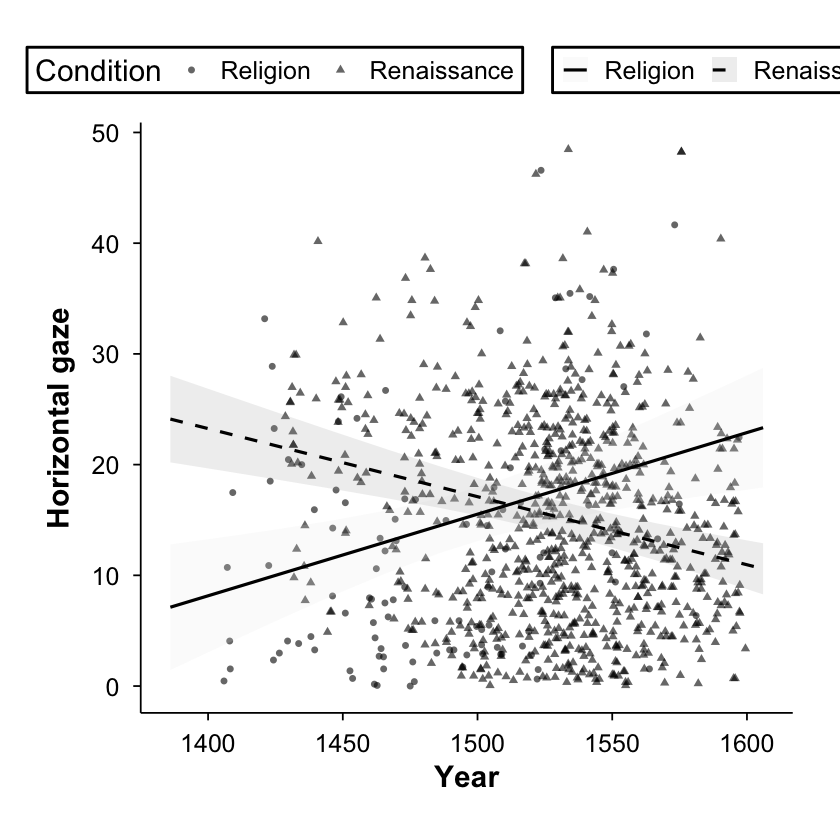

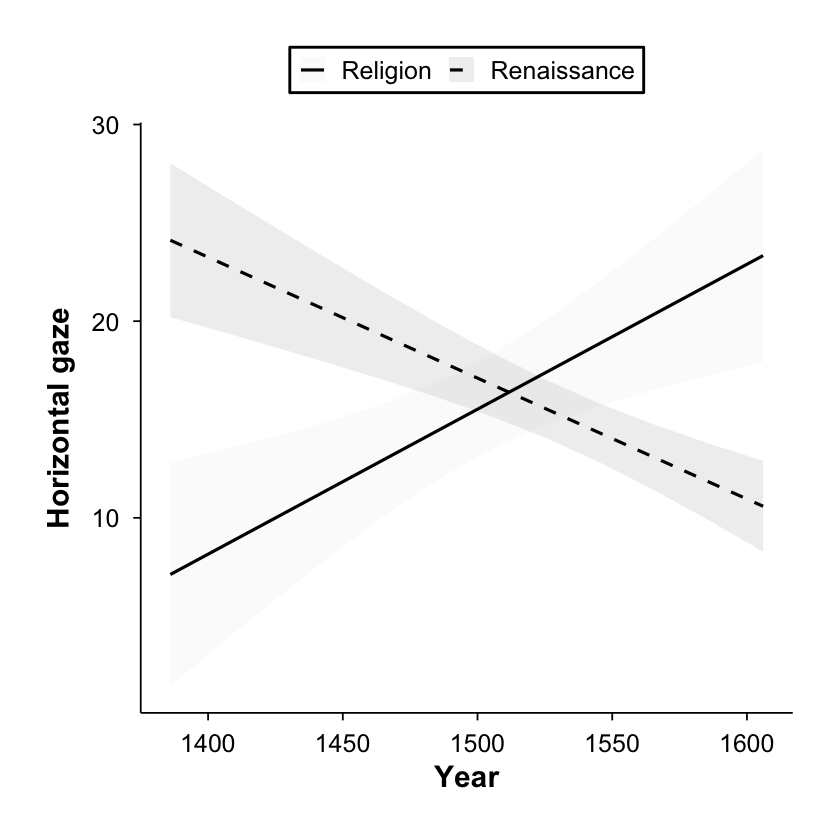

In [15]:
# Fit linear mixed model with sdate × Condition interaction to compare gaze trends in Renaissance vs. religious paintings; plot predicted trajectories.
# head(metadf)
metadf %>% filter(SCHOOL != 'Other' & SCHOOL != 'Finnish' &
                  SCHOOL != 'Norwegian',date>1400,date<1600,
                  headPitch<90,headPitch>-90,Condition!='Post_Renaissance') %>%
                  mutate(sdate=scale(date,center=T,scale=F),gaze_cen=abs(gazeYaw)) -> metadf_rel
metadf_rel %>% lmer(gaze_cen~sdate*Condition+ (1 |SCHOOL)+(1 |AUTHOR),data=.) -> fit1

metadf_rel %>% filter(Condition=='Religion') %>% summarise(n=n())
fit1 %>% summary()

glm_p <- ggpredict(fit1, terms = c("sdate",'Condition'))
hoge <- round(mean(metadf_rel$date,na.rm=T))
glm_p %<>% as.data.frame() %>% mutate(date=hoge+x)

# head(df)
emm.result <- emmeans(fit1, ~ Condition, at = list(date=1400),pbkrtest.limit = 4560)
summary(emm.result, infer=TRUE)
pairs(emm.result,pbkrtest.limit = 4560)

emm.gen <- emtrends(fit1, "Condition", var = "sdate",pbkrtest.limit = 4560)
summary(emm.gen, infer=TRUE)
pairs(emm.gen,pbkrtest.limit = 4560)

# groupごとに線種を割り当て（最大6種まで想定）
groups <- unique(glm_p$group)
lt_vals <- c("solid","dashed","dotdash","twodash","longdash","dotted")[seq_along(groups)]

(p <- ggplot() +
 geom_point(data = metadf_rel, aes(x = date, y = gaze_cen, shape = Condition),
             size = 1.4, alpha = 0.6, position = position_jitter(width = 2, height = 0)) + 
 geom_ribbon(data = glm_p, aes(x = date, y = predicted, linetype = group,ymin = conf.low, ymax = conf.high, fill = group),
              alpha = 0.18, colour = NA) +
 geom_line(data = glm_p, aes(x = date, y = predicted, linetype = group),size = 0.9, colour = "black") +
  scale_x_continuous(breaks = seq(1400, 1600, 50)) +
  scale_linetype_manual(values = lt_vals, guide = guide_legend(title = NULL)) +
  scale_fill_grey(start = 0.92, end = 0.65, guide = guide_legend(title = NULL)) +
  labs(y = "Horizontal gaze", x = "Year"))
# ggsave('Gaze_Shift_Left_Religion.png',p)

(p <- ggplot() +
 geom_ribbon(data = glm_p, aes(x = date, y = predicted, linetype = group,ymin = conf.low, ymax = conf.high, fill = group),
              alpha = 0.18, colour = NA) +
 geom_line(data = glm_p, aes(x = date, y = predicted, linetype = group),size = 0.9, colour = "black") +
  scale_x_continuous(breaks = seq(1400, 1600, 50)) +
  scale_linetype_manual(values = lt_vals, guide = guide_legend(title = NULL)) +
  scale_fill_grey(start = 0.92, end = 0.65, guide = guide_legend(title = NULL)) +
  labs(y = "Horizontal gaze", x = "Year"))
# ggsave('Gaze_Shift_Left_Religion.png',p)

In [16]:
# Cleaner version: data preparation and model fitting for the religious vs. secular gaze comparison.
# ==========================================
# DATA PREPARATION
# ==========================================

metadf %>% 
  filter(
    SCHOOL != 'Other' & SCHOOL != 'Finnish' & SCHOOL != 'Norwegian',
    date > 1400, date < 1600,
    headPitch < 90, headPitch > -90,
    Condition != 'Post_Renaissance'
  ) %>%
  mutate(
    sdate    = scale(date, center = T, scale = F),
    gaze_cen = abs(gazeYaw)
  ) -> metadf_rel

# Sample size per condition
cat("Sample sizes by Condition:\n")
metadf_rel %>% 
  group_by(Condition) %>% 
  summarise(n = n(), .groups = 'drop') %>%
  print()

# ==========================================
# FIT INTERACTION MODEL
# ==========================================

metadf_rel %>% 
  lmer(
    gaze_cen ~ sdate * Condition + (1 | SCHOOL) + (1 | AUTHOR),
    data = .
  ) -> fit1

summary(fit1)

# Extract fixed effects with all statistics
fixed_summary <- summary(fit1)$coefficients %>%
  as.data.frame() %>%
  rownames_to_column("Predictor") %>%
  rename(
    Beta    = Estimate,
    SE      = `Std. Error`,
    df      = df,
    t       = `t value`,
    p       = `Pr(>|t|)`
  ) %>%
  select(Predictor, Beta, SE, df, t, p)

print("FIXED EFFECTS (with interaction):")
print(fixed_summary)

# 95% CI using Wald method
ci_fit1 <- confint(fit1, method = "Wald") %>%
  as.data.frame() %>%
  rownames_to_column("Predictor") %>%
  rename(CI_lower = `2.5 %`, CI_upper = `97.5 %`) %>%
  filter(!grepl("\\.|sigma", Predictor))

print("95% CONFIDENCE INTERVALS:")
print(ci_fit1)

# Calculate standard deviations
sd_outcome <- sd(metadf_rel$gaze_cen, na.rm = TRUE)
sd_sdate   <- sd(metadf_rel$sdate,    na.rm = TRUE)

# Extract beta estimates
beta_estimates <- summary(fit1)$coefficients[, "Estimate"]

# Calculate standardized betas for continuous predictor
# (interaction terms typically left unstandardized in mixed models)
beta_std <- c(
  NA,  # Intercept
  beta_estimates[2] * (sd_sdate / sd_outcome),  # sdate main effect
  NA, NA  # Categorical Condition effects
)

cat("Standardized β:\n")
print(beta_std)

beta_std

Sample sizes by Condition:
# A tibble: 2 × 2
  Condition       n
  <chr>       <int>
1 Religion      110
2 Renaissance   860


Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: gaze_cen ~ sdate * Condition + (1 | SCHOOL) + (1 | AUTHOR)
   Data: .

REML criterion at convergence: 6961.4

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.6920 -0.7158 -0.0559  0.5789  3.7666 

Random effects:
 Groups   Name        Variance Std.Dev.
 AUTHOR   (Intercept) 23.337   4.831   
 SCHOOL   (Intercept)  1.131   1.063   
 Residual             65.337   8.083   
Number of obs: 970, groups:  AUTHOR, 187; SCHOOL, 11

Fixed effects:
                            Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)                 17.43953    1.36811  39.55714  12.747 1.37e-15 ***
sdate                        0.07370    0.02312 506.88314   3.188  0.00152 ** 
ConditionRenaissance        -1.93286    1.19287 939.02679  -1.620  0.10549    
sdate:ConditionRenaissance  -0.13519    0.02505 598.99638  -5.397 9.78e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 

[1] "FIXED EFFECTS (with interaction):"
                   Predictor       Beta         SE        df         t
1                (Intercept) 17.4395327 1.36810583  39.55714 12.747210
2                      sdate  0.0737050 0.02311845 506.88314  3.188147
3       ConditionRenaissance -1.9328641 1.19286570 939.02679 -1.620353
4 sdate:ConditionRenaissance -0.1351904 0.02504982 598.99638 -5.396862
             p
1 1.372759e-15
2 1.520335e-03
3 1.054921e-01
4 9.782789e-08
[1] "95% CONFIDENCE INTERVALS:"
                   Predictor    CI_lower    CI_upper
1                (Intercept) 14.75809459 20.12097091
2                      sdate  0.02839368  0.11901632
3       ConditionRenaissance -4.27083786  0.40510976
4 sdate:ConditionRenaissance -0.18428714 -0.08609366
Standardized β:
              sdate                     
       NA 0.3127945        NA        NA 


sdate                     
       NA 0.3127945        NA        NA

In [17]:
# Extract random-effects variance components and intraclass correlations from the religious/secular model.
# Extract variance components
var_comp <- VarCorr(fit1)

var_school   <- as.numeric(var_comp$SCHOOL[1, 1])
var_author   <- as.numeric(var_comp$AUTHOR[1, 1])
var_residual <- attr(var_comp, "sc")^2
var_total    <- var_school + var_author + var_residual

random_table <- data.frame(
  Group    = c("School", "Author", "Residual"),
  Variance = c(var_school, var_author, var_residual),
  SD       = c(sqrt(var_school), sqrt(var_author), sqrt(var_residual)),
  ICC      = c(
    round(var_school / var_total, 3),
    round(var_author / var_total, 3),
    NA
  )
) %>%
  mutate(across(where(is.numeric), ~round(.x, 3)))

print("RANDOM EFFECTS:")
print(random_table)

# ============================================
# COMPILE FIXED EFFECTS TABLE
# ============================================

results_fixed <- fixed_summary %>%
  left_join(ci_fit1, by = "Predictor") %>%
  mutate(
    Predictor = c(
      "(Intercept)",
      "Date (centered)",
      "Condition: Renaissance",
      "Interaction"
    ),
    `95% CI` = paste0(
      "[", round(CI_lower, 3), ", ", round(CI_upper, 3), "]"
    ),
    Beta     = round(Beta, 3),
    SE       = round(SE, 3),
    t        = round(t, 2),
    df       = round(df, 2),
    p        = ifelse(p < 0.001, "<.001", round(p, 3)),
    Beta_std = round(beta_std, 3)
  ) %>%
  select(Predictor, Beta, SE, `95% CI`, t, df, p, Beta_std)

cat("\n========================================\n")
cat("FIXED EFFECTS TABLE\n")
cat("========================================\n\n")
print(results_fixed)

cat("\n\nRANDOM EFFECTS TABLE:\n")
print(random_table)


[1] "RANDOM EFFECTS:"
     Group Variance    SD   ICC
1   School    1.131 1.063 0.013
2   Author   23.337 4.831 0.260
3 Residual   65.337 8.083    NA

FIXED EFFECTS TABLE

               Predictor   Beta    SE           95% CI     t     df     p
1            (Intercept) 17.440 1.368 [14.758, 20.121] 12.75  39.56 <.001
2        Date (centered)  0.074 0.023   [0.028, 0.119]  3.19 506.88 0.002
3 Condition: Renaissance -1.933 1.193  [-4.271, 0.405] -1.62 939.03 0.105
4            Interaction -0.135 0.025 [-0.184, -0.086] -5.40 599.00 <.001
  Beta_std
1       NA
2    0.313
3       NA
4       NA


RANDOM EFFECTS TABLE:
     Group Variance    SD   ICC
1   School    1.131 1.063 0.013
2   Author   23.337 4.831 0.260
3 Residual   65.337 8.083    NA


In [18]:
# Compute estimated marginal means at year = 1400 to compare gaze deviation between religious and secular portraits at the start of the period.
# ==========================================
# ESTIMATED MARGINAL MEANS AT DATE = 1400
# ==========================================

emm.result <- emmeans(
  fit1, 
  ~ Condition, 
  at = list(sdate = mean(metadf_rel$sdate, na.rm = T) - (1400 - mean(metadf_rel$date, na.rm = T))),
  pbkrtest.limit = 4560
)

cat("\n========================================\n")
cat("ESTIMATED MARGINAL MEANS (at Year = 1400)\n")
cat("========================================\n")
summary(emm.result, infer = TRUE)

# Pairwise comparisons
cat("\nPAIRWISE COMPARISONS:\n")
pairs(emm.result, pbkrtest.limit = 4560)

# Save EMM results
emm_table <- summary(emm.result, infer = TRUE) %>%
  as.data.frame() %>%
  mutate(
    Condition = as.character(Condition),
    emmean    = round(emmean, 3),
    SE        = round(SE, 3),
    lower.CL  = round(lower.CL, 3),
    upper.CL  = round(upper.CL, 3),
    t.ratio   = round(t.ratio, 2),
    p.value   = ifelse(p.value < 0.001, "<.001", round(p.value, 3))
  ) %>%
  select(Condition, emmean, SE, lower.CL, upper.CL, t.ratio, p.value) %>%
  rename(
    "Condition" = Condition,
    "EMM" = emmean,
    "SE" = SE,
    "95% CI Lower" = lower.CL,
    "95% CI Upper" = upper.CL,
    "t" = t.ratio,
    "p" = p.value
  )

print(emm_table)


NOTE: Results may be misleading due to involvement in interactions




ESTIMATED MARGINAL MEANS (at Year = 1400)


,Condition,emmean,SE,df,lower.CL,upper.CL,t.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Religion,26.690042,3.74503,657.9566,19.336390,34.04369,7.126789,2.708435e-12
2,Renaissance,7.789807,1.67796,101.3957,4.461343,11.11827,4.642426,1.034112e-05



PAIRWISE COMPARISONS:


 contrast               estimate   SE  df t.ratio p.value
 Religion - Renaissance     18.9 3.84 833   4.920  <.0001

Degrees-of-freedom method: kenward-roger 

    Condition   EMM    SE 95% CI Lower 95% CI Upper    t     p
1    Religion 26.69 3.745       19.336       34.044 7.13 <.001
2 Renaissance  7.79 1.678        4.461       11.118 4.64 <.001


## Study 3: The prevalence of eye-gaze will persist even after the Renaissance

In [19]:
# Prepare post-Renaissance data (date > 1650) and fit linear mixed model predicting absolute gaze deviation from year.
# ==========================================
# DATA PREPARATION
# ==========================================

post_renai <- metadf %>% 
  filter(
    SCHOOL != 'Other' & SCHOOL != 'Finnish' & SCHOOL != 'Norwegian',
    date > 1650,
    Condition == 'Post_Renaissance',
    headPitch < 90, headPitch > -90
  )

post_renai %<>% mutate(
  sdate    = scale(date, center = T, scale = F),
  gaze_cen = abs(gazeYaw)
)

cat("Sample size:", nrow(post_renai), "\n")

# ==========================================
# FIT MODEL
# ==========================================

post_renai %>% 
  lmer(
    gaze_cen ~ sdate + (1 | SCHOOL) + (1 | AUTHOR),
    data = .
  ) -> fit2_post

summary(fit2_post)


Sample size: 1140 


Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: gaze_cen ~ sdate + (1 | SCHOOL) + (1 | AUTHOR)
   Data: .

REML criterion at convergence: 8174.6

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.0202 -0.7018 -0.1335  0.5275  4.6759 

Random effects:
 Groups   Name        Variance Std.Dev.
 AUTHOR   (Intercept)  7.126   2.669   
 SCHOOL   (Intercept)  2.877   1.696   
 Residual             69.208   8.319   
Number of obs: 1140, groups:  AUTHOR, 394; SCHOOL, 19

Fixed effects:
             Estimate Std. Error        df t value Pr(>|t|)    
(Intercept) 1.242e+01  5.825e-01 8.609e+00  21.317 9.45e-09 ***
sdate       1.452e-02  5.412e-03 2.030e+02   2.683   0.0079 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
      (Intr)
sdate 0.040 

[1] "FIXED EFFECTS:"
    Predictor        Beta         SE         df         t            p
1 (Intercept) 12.41638725 0.58247403   8.609471 21.316637 9.448060e-09
2       sdate  0.01451826 0.00541177 202.951506  2.682719 7.904596e-03
[1] "95% CONFIDENCE INTERVALS:"
    Predictor     CI_lower    CI_upper
1 (Intercept) 11.274759121 13.55801537
2       sdate  0.003911386  0.02512513
Standardized β:
                sdate 
        NA 0.09907168 
[1] "RANDOM EFFECTS:"
     Group Variance    SD   ICC
1   School    2.877 1.696 0.036
2   Author    7.126 2.669 0.090
3 Residual   69.208 8.319    NA
[1] "MODEL FIT STATISTICS:"
       Statistic   Value
1 N observations  1140.0
2      N Schools    19.0
3      N Authors   394.0
4 Log-likelihood -4087.3
5            AIC  8184.6
6            BIC  8209.8

COMPLETE RESULTS: Post-Renaissance Model

FIXED EFFECTS:
        Predictor   Beta    SE           95% CI     t     df     p Beta_std
1     (Intercept) 12.416 0.582 [11.275, 13.558] 21.32   8.61 <.001  

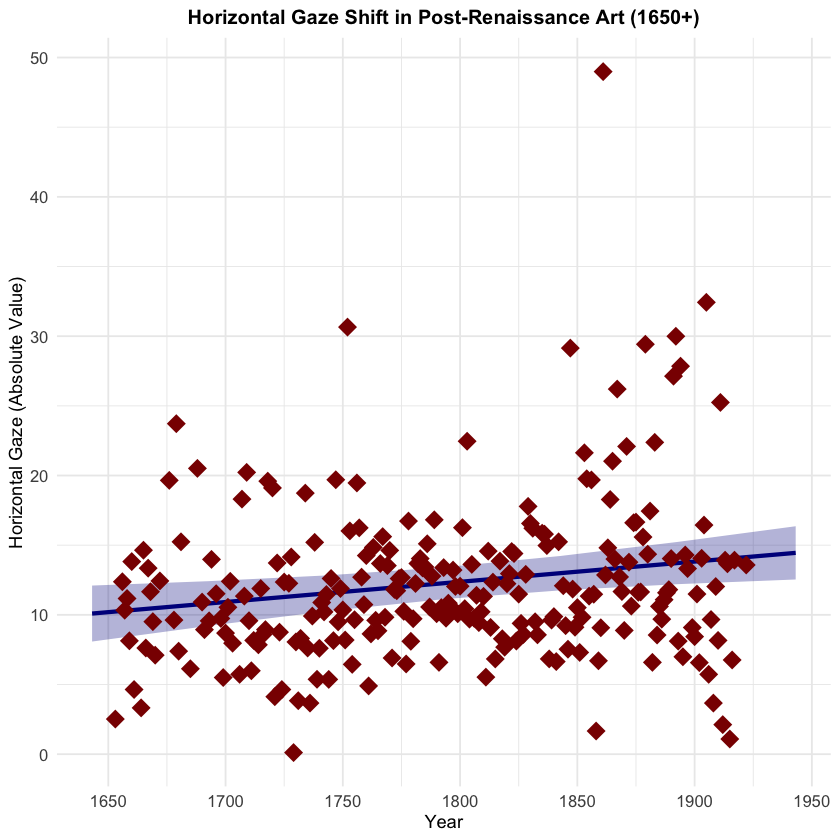

In [20]:
# Extract and print fixed-effects coefficients and 95% CIs from the post-Renaissance gaze trend model.
# Extract fixed effects with all statistics
fixed_summary <- summary(fit2_post)$coefficients %>%
  as.data.frame() %>%
  rownames_to_column("Predictor") %>%
  rename(
    Beta    = Estimate,
    SE      = `Std. Error`,
    df      = df,
    t       = `t value`,
    p       = `Pr(>|t|)`
  ) %>%
  select(Predictor, Beta, SE, df, t, p)

print("FIXED EFFECTS:")
print(fixed_summary)

# 95% CI using Wald method
ci_fit2_post <- confint(fit2_post, method = "Wald") %>%
  as.data.frame() %>%
  rownames_to_column("Predictor") %>%
  rename(CI_lower = `2.5 %`, CI_upper = `97.5 %`) %>%
  filter(!grepl("\\.|sigma", Predictor))

print("95% CONFIDENCE INTERVALS:")
print(ci_fit2_post)
# Calculate standard deviations for standardization
sd_outcome <- sd(post_renai$gaze_cen, na.rm = TRUE)
sd_sdate   <- sd(post_renai$sdate,    na.rm = TRUE)

# Extract beta coefficients
beta_estimates <- summary(fit2_post)$coefficients[, "Estimate"]

# Calculate standardized betas
beta_std <- c(
  NA,  # Intercept (not standardized)
  beta_estimates[2] * (sd_sdate / sd_outcome)  # sdate
)

cat("Standardized β:\n")
print(beta_std)

# Extract variance components
var_comp <- VarCorr(fit2_post)

var_school   <- as.numeric(var_comp$SCHOOL[1, 1])
var_author   <- as.numeric(var_comp$AUTHOR[1, 1])
var_residual <- attr(var_comp, "sc")^2
var_total    <- var_school + var_author + var_residual

# Create random effects table
random_table <- data.frame(
  Group    = c("School", "Author", "Residual"),
  Variance = c(var_school, var_author, var_residual),
  SD       = c(sqrt(var_school), sqrt(var_author), sqrt(var_residual)),
  ICC      = c(
    round(var_school / var_total, 3),
    round(var_author / var_total, 3),
    NA
  )
) %>%
  mutate(across(where(is.numeric), ~round(.x, 3)))

print("RANDOM EFFECTS:")
print(random_table)

# Additional model information
model_stats <- data.frame(
  Statistic = c(
    "N observations",
    "N Schools",
    "N Authors",
    "Log-likelihood",
    "AIC",
    "BIC"
  ),
  Value = c(
    nobs(fit2_post),
    length(unique(post_renai$SCHOOL)),
    length(unique(post_renai$AUTHOR)),
    round(logLik(fit2_post)[1], 2),
    round(AIC(fit2_post), 2),
    round(BIC(fit2_post), 2)
  )
)

print("MODEL FIT STATISTICS:")
print(model_stats)

# ============================================
# COMPILE COMPLETE RESULTS TABLE
# ============================================

results_fixed <- fixed_summary %>%
  left_join(ci_fit2_post, by = "Predictor") %>%
  mutate(
    Predictor = c("(Intercept)", "Date (centered)"),
    `95% CI`  = paste0(
      "[", round(CI_lower, 3), ", ", round(CI_upper, 3), "]"
    ),
    Beta      = round(Beta, 3),
    SE        = round(SE, 3),
    t         = round(t, 2),
    df        = round(df, 2),
    p         = ifelse(p < 0.001, "<.001", round(p, 3)),
    Beta_std  = round(beta_std, 3)
  ) %>%
  select(Predictor, Beta, SE, `95% CI`, t, df, p, Beta_std)

cat("\n========================================\n")
cat("COMPLETE RESULTS: Post-Renaissance Model\n")
cat("========================================\n\n")

cat("FIXED EFFECTS:\n")
print(results_fixed)

cat("\n\nRANDOM EFFECTS:\n")
print(random_table)

cat("\n\nMODEL FIT STATISTICS:\n")
print(model_stats)
# ==========================================
# GENERATE PREDICTIONS
# ==========================================

# Generate predictions using ggeffects
glm_p <- ggpredict(fit2_post, terms = "sdate [-160:140 by=50]")

# Convert sdate back to actual dates
glm_p %<>% mutate(date = mean(post_renai$date, na.rm = T) + x)

print("PREDICTIONS WITH 95% CI:")
print(glm_p)

# ==========================================
# CREATE VISUALIZATION
# ==========================================

p <- ggplot() + 
  # Predicted line
  geom_line(
    data = glm_p, 
    aes(x = date, y = predicted), 
    show.legend = FALSE,
    size = 1.2,
    color = "darkblue"
  ) + 
  # Confidence ribbon
  geom_ribbon(
    data = glm_p, 
    aes(x = date, ymin = conf.low, ymax = conf.high), 
    alpha = 0.3,
    show.legend = FALSE,
    fill = "darkblue"
  ) +
  # Observed means
  stat_summary(
    data = filter(
      metadf,
      SCHOOL != 'Other' & SCHOOL != 'Finnish' & SCHOOL != 'Norwegian',
      date > 1650,
      headPitch < 90, headPitch > -90,
      Condition == 'Post_Renaissance'
    ), 
    aes(x = date, y = abs(gazeYaw)), 
    fun = mean, 
    geom = "point", 
    size = 5, 
    shape = 18,
    color = "darkred",
    position = position_dodge(width = 0.75)
  ) +
  scale_x_continuous(breaks = seq(1650, 1950, 50)) +
  labs(
    title = "Horizontal Gaze Shift in Post-Renaissance Art (1650+)",
    x = "Year",
    y = "Horizontal Gaze (Absolute Value)"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 12),
    axis.title = element_text(size = 11),
    axis.text = element_text(size = 10)
  )

print(p)

# Save plot
# ggsave('Gaze_Shift_Post_Renai_only.png', p, dpi = 300, width = 10, height = 6)

# ==========================================
# GENERATE LATEX TABLES
# ==========================================

# ── Fixed Effects Table ──────────────────────────────
print(
  xtable(
    results_fixed,
    caption = "Fixed Effects Estimates (Post-Renaissance, 1650+)",
    label   = "tab:fixed_effects_post_renai",
    digits  = 3
  ),
  include.rownames = FALSE,
  booktabs         = TRUE,
  sanitize.text.function = identity,
  file = "result7_fixed_effects_post_renai.tex"
)

# ── Random Effects Table ─────────────────────────────
print(
  xtable(
    random_table,
    caption = "Random Effects Variance Components (Post-Renaissance, 1650+)",
    label   = "tab:random_effects_post_renai",
    digits  = 3
  ),
  include.rownames = FALSE,
  booktabs         = TRUE,
  file = "result7_random_effects_post_renai.tex"
)

# # ── Model Fit Statistics ─────────────────────────────
# print(
#   xtable(
#     model_stats,
#     caption = "Model Fit Statistics (Post-Renaissance, 1650+)",
#     label   = "tab:model_fit_post_renai",
#     digits  = 2
#   ),
#   include.rownames = FALSE,
#   booktabs         = TRUE,
#   file = "result7_model_fit_post_renai.tex"
# )

# # ── Predictions Table ────────────────────────────────
# predictions_table <- glm_p %>%
#   select(date, predicted, conf.low, conf.high) %>%
#   mutate(
#     date = round(date, 0),
#     predicted = round(predicted, 3),
#     conf.low = round(conf.low, 3),
#     conf.high = round(conf.high, 3)
#   ) %>%
#   rename(
#     "Year" = date,
#     "Predicted Gaze" = predicted,
#     "95% CI Lower" = conf.low,
#     "95% CI Upper" = conf.high
#   )

# print(
#   xtable(
#     predictions_table,
#     caption = "Model Predictions for Gaze (Post-Renaissance)",
#     label   = "tab:predictions_post_renai",
#     digits  = 3
#   ),
#   include.rownames = FALSE,
#   booktabs         = TRUE,
#   file = "result7_predictions_post_renai.tex"
# )


### Popularity

In [21]:
# Quick version: fit mixed model predicting web hits from gaze, sitter fame, and year in Renaissance portraits.
metadf %>% filter(date > 1400 ,date < 1600, headPitch < 90, headPitch > -90,
    # BUG FIX: | (OR) changed to & (AND)
    Condition=='Renaissance', SCHOOL != 'Other' & SCHOOL != 'Finnish' & SCHOOL != 'Norwegian') %>% 
    mutate(sdate = scale(date,center=T,scale=F)) -> metadf_post
metadf_post %>% lmer(log_hits~scale(gaze_cen)+scale(log_fame) + sdate + (1 |SCHOOL) + (1|AUTHOR),data=.) -> fit1
summary(fit1)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: log_hits ~ scale(gaze_cen) + scale(log_fame) + sdate + (1 | SCHOOL) +  
    (1 | AUTHOR)
   Data: .

REML criterion at convergence: 988.9

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.57363 -0.54584 -0.01097  0.62279  2.20170 

Random effects:
 Groups   Name        Variance Std.Dev.
 AUTHOR   (Intercept) 1.1168   1.0568  
 SCHOOL   (Intercept) 0.5181   0.7198  
 Residual             1.6343   1.2784  
Number of obs: 270, groups:  AUTHOR, 65; SCHOOL, 8

Fixed effects:
                  Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)       4.152194   0.346281   3.417628  11.991 0.000652 ***
scale(gaze_cen)  -0.040145   0.091909 254.526388  -0.437 0.662633    
scale(log_fame)   0.604211   0.093820 259.255808   6.440 5.76e-10 ***
sdate            -0.001522   0.004228  87.104681  -0.360 0.719751    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 

In [22]:
# Cleaner version: data preparation and model fitting for Renaissance cultural prominence ~ gaze deviation.
# ==========================================
# DATA PREPARATION
# ==========================================

metadf %>% 
  filter(
    date > 1400, date < 1600,
    headPitch < 90, headPitch > -90,
    Condition == 'Renaissance',
    SCHOOL != 'Other' & SCHOOL != 'Finnish' & SCHOOL != 'Norwegian'
  ) %>% 
  mutate(sdate = scale(date, center = TRUE, scale = FALSE)) -> metadf_post

# Sample size
cat("Sample size for Renaissance data:", nrow(metadf_post), "\n")

# ==========================================
# FIT MODEL
# ==========================================

metadf_post %>% 
  lmer(
    log_hits ~ scale(gaze_cen) + scale(log_fame) + sdate + (1 | SCHOOL) + (1 | AUTHOR),
    data = .
  ) -> fit1

# Summary of the model
# summary(fit1)
# Extract fixed effects with all statistics
fixed_summary <- summary(fit1)$coefficients %>%
  as.data.frame() %>%
  rownames_to_column("Predictor") %>%
  rename(
    Beta    = Estimate,
    SE      = `Std. Error`,
    df      = df,
    t       = `t value`,
    p       = `Pr(>|t|)`
  ) %>%
  select(Predictor, Beta, SE, df, t, p)

# print("FIXED EFFECTS:")
# print(fixed_summary)

# 95% CI using Wald method
ci_fit1 <- confint(fit1, method = "Wald") %>%
  as.data.frame() %>%
  rownames_to_column("Predictor") %>%
  rename(CI_lower = `2.5 %`, CI_upper = `97.5 %`) %>%
  filter(!grepl("\\.|sigma", Predictor))

# print("95% CONFIDENCE INTERVALS:")
# print(ci_fit1)

# Calculate standard deviations for standardization
sd_outcome  <- sd(metadf_post$log_hits, na.rm = TRUE)
sd_gaze_cen <- sd(metadf_post$gaze_cen, na.rm = TRUE)
sd_log_fame <- sd(metadf_post$log_fame, na.rm = TRUE)

# Extract beta estimates
beta_estimates <- summary(fit1)$coefficients[, "Estimate"]

# Calculate standardized betas
beta_std <- c(
  NA,  # Intercept (not standardized)
  beta_estimates[2] * (sd_gaze_cen / sd_outcome),  # gaze_cen
  beta_estimates[3] * (sd_log_fame / sd_outcome),  # log_fame
  beta_estimates[4]  # sdate (mean-centered, not standardized)
)

# cat("Standardized β:\n")
# print(beta_std)

# Extract variance components
var_comp <- VarCorr(fit1)

var_school   <- as.numeric(var_comp$SCHOOL[1, 1])
var_author   <- as.numeric(var_comp$AUTHOR[1, 1])
var_residual <- attr(var_comp, "sc")^2
var_total    <- var_school + var_author + var_residual

random_table <- data.frame(
  Group    = c("School", "Author", "Residual"),
  Variance = c(var_school, var_author, var_residual),
  SD       = c(sqrt(var_school), sqrt(var_author), sqrt(var_residual)),
  ICC      = c(
    round(var_school / var_total, 3),
    round(var_author / var_total, 3),
    NA
  )
) %>%
  mutate(across(where(is.numeric), ~round(.x, 3)))

# cat("\nRANDOM EFFECTS:\n")
# print(random_table)
# ============================================
# COMPILE COMPLETE RESULTS TABLE
# ============================================

results_fixed <- fixed_summary %>%
  left_join(ci_fit1, by = "Predictor") %>%
  mutate(
    Predictor = c(
      "(Intercept)",
      "Gaze (centered)",
      "Log Fame (centered)",
      "Date (centered)"
    ),
    `95% CI`  = paste0("[", round(CI_lower, 3), ", ", round(CI_upper, 3), "]"),
    Beta      = round(Beta, 3),
    SE        = round(SE, 3),
    t         = round(t, 2),
    df        = round(df, 2),
    p         = ifelse(p < 0.001, "<.001", round(p, 3)),
    Beta_std  = round(beta_std, 3)
  ) %>%
  select(Predictor, Beta, SE, `95% CI`, t, df, p, Beta_std)

cat("\n===== FIXED EFFECTS =====\n")
print(results_fixed)

cat("\n===== RANDOM EFFECTS =====\n")
print(random_table)

# ==========================================
# GENERATE LATEX TABLES
# ==========================================

# ── Fixed Effects Table ──────────────────────────────
print(
  xtable(
    results_fixed,
    caption = "Fixed Effects Estimates (Renaissance, 1400–1600)",
    label   = "tab:fixed_effects_fit1",
    digits  = 3
  ),
  include.rownames = FALSE,
  booktabs         = TRUE,
  sanitize.text.function = identity,
  file = "result8_fixed_effects_popularity_postR.tex"
)

# ── Random Effects Table ─────────────────────────────
print(
  xtable(
    random_table,
    caption = "Random Effects Variance Components (Renaissance, 1400–1600)",
    label   = "tab:random_effects_fit1",
    digits  = 3
  ),
  include.rownames = FALSE,
  booktabs         = TRUE,
  file = "result8_random_effects_popularity_postR.tex"
)


Sample size for Renaissance data: 860 

===== FIXED EFFECTS =====
            Predictor   Beta    SE         95% CI     t     df     p Beta_std
1         (Intercept)  4.152 0.346 [3.473, 4.831] 11.99   3.42 <.001       NA
2     Gaze (centered) -0.040 0.092  [-0.22, 0.14] -0.44 254.53 0.663   -0.178
3 Log Fame (centered)  0.604 0.094  [0.42, 0.788]  6.44 259.26 <.001    0.359
4     Date (centered) -0.002 0.004 [-0.01, 0.007] -0.36  87.10  0.72   -0.002

===== RANDOM EFFECTS =====
     Group Variance    SD   ICC
1   School    0.518 0.720 0.158
2   Author    1.117 1.057 0.342
3 Residual    1.634 1.278    NA


In [23]:
# Fit mixed model predicting gaze deviation from sitter fame and year, checking whether fame alone drives gaze patterns.
metadf %>% filter(date > 1400 ,date < 1600, headPitch < 90, headPitch > -90,
    # BUG FIX: | (OR) changed to & (AND)
    Condition=='Renaissance', SCHOOL != 'Other' & SCHOOL != 'Finnish' & SCHOOL != 'Norwegian') %>% 
    mutate(sdate = scale(date,center=T,scale=F)) -> metadf_post
metadf_post %>% lmer(gaze_cen~+scale(log_fame,center=T,scale=F) + sdate + (1 |SCHOOL) + (1|AUTHOR),data=.) -> fit1
summary(fit1)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: gaze_cen ~ +scale(log_fame, center = T, scale = F) + sdate +  
    (1 | SCHOOL) + (1 | AUTHOR)
   Data: .

REML criterion at convergence: 2004.4

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.5145 -0.6653 -0.0021  0.5511  3.4111 

Random effects:
 Groups   Name        Variance Std.Dev.
 AUTHOR   (Intercept) 18.469   4.298   
 SCHOOL   (Intercept)  1.445   1.202   
 Residual             65.608   8.100   
Number of obs: 279, groups:  AUTHOR, 68; SCHOOL, 8

Fixed effects:
                                        Estimate Std. Error        df t value
(Intercept)                             15.43309    0.99228   3.16917  15.553
scale(log_fame, center = T, scale = F)   0.78386    0.44561 266.13032   1.759
sdate                                   -0.04684    0.02046  74.80273  -2.290
                                       Pr(>|t|)    
(Intercept)                            0.000424 **

### Gaze within three-quarters

,Condition,headYaw,gaze_cen,AUTHOR,BORN.DIED,date,SCHOOL,TIMEFRAME
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<int>,<fct>,<chr>
1,Renaissance,60.103273,40.164341,"LIPPI, Fra Filippo","(b. 1406, Firenze, d. 1469, Spoleto)",1440,Italian,1401-1450
2,Renaissance,21.829692,15.870931,"MEMLING, Hans","(b. ca. 1440, Seligenstadt, d. 1494, Bruges)",1467,Flemish,1451-1500
3,Renaissance,-26.184171,13.235325,RAFFAELLO Sanzio,"(b. 1483, Urbino, d. 1520, Roma)",1512,Italian,1501-1550
4,Renaissance,35.580679,28.246819,"HOLBEIN, Hans the Younger","(b. 1497, Augsburg, d. 1543, London)",1519,German,1501-1550
5,Renaissance,7.849522,5.614986,"HOLBEIN, Hans the Younger","(b. 1497, Augsburg, d. 1543, London)",1536,German,1501-1550
6,Renaissance,-36.898482,26.298763,TIZIANO Vecellio,"(b. 1490, Pieve di Cadore, d. 1576, Venezia)",1510,Italian,1501-1550


`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


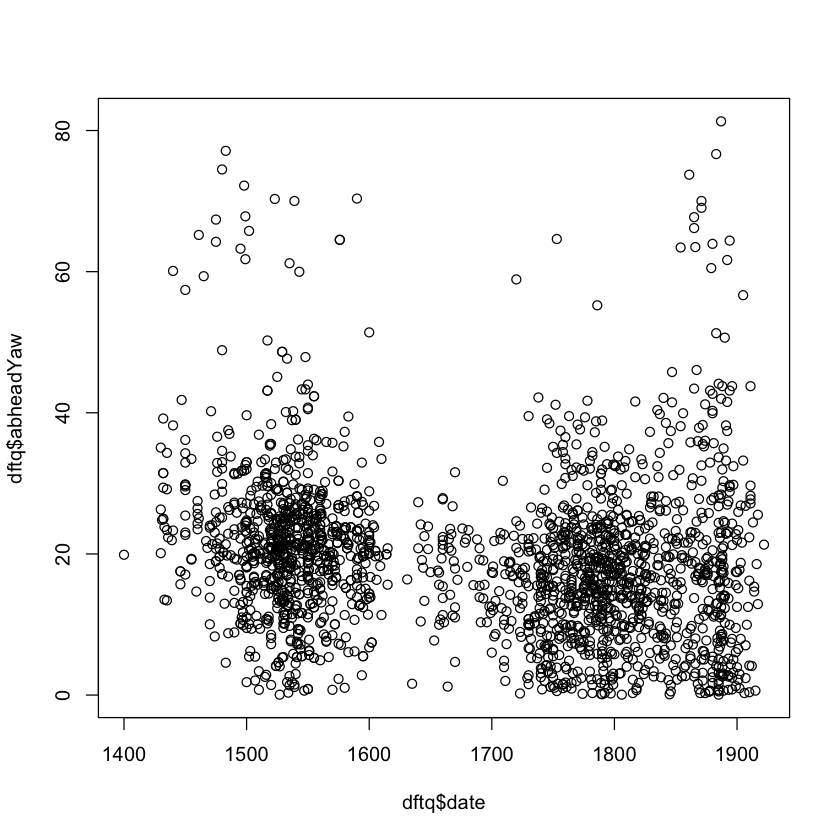

meanhY,sdhY
<dbl>,<dbl>
19.18619,11.16153


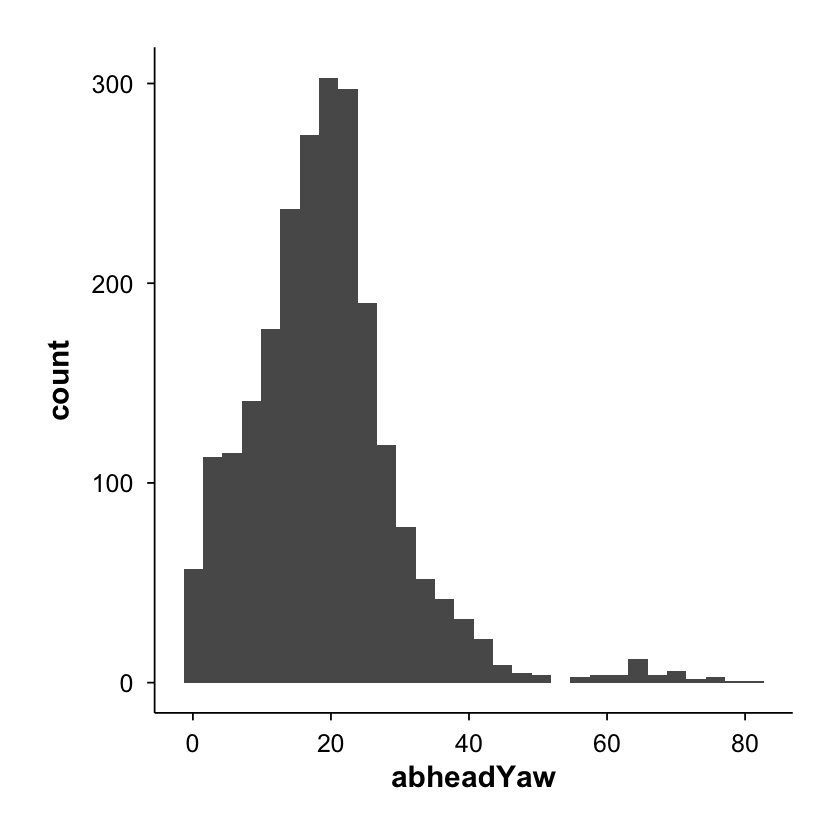

In [24]:
# Categorise all portraits by head pose (frontal / three-quarter / profile) based on absolute head yaw angle.
metadf %>% select(Condition,headYaw,gaze_cen,AUTHOR,BORN.DIED,date,SCHOOL,TIMEFRAME) %>% filter(Condition!="Religion") -> dftq
head(dftq)
dftq %<>% mutate(abheadYaw= abs(headYaw))
plot(dftq$date,dftq$abheadYaw)
ggplot(data=dftq,aes(x=abheadYaw)) + geom_histogram()
dftq %>% summarise(meanhY=mean(abheadYaw),sdhY=sd(abheadYaw))

dftq$pose_cat %<>% dplyr::case_when(
  dftq$abheadYaw < 15 ~ "frontal",
  dftq$abheadYaw < 45 ~ "three_quarters",
  TRUE ~ "profile"
)

#### three-quarter for the Renaissance 

In [25]:
# Quick version: fit mixed model predicting gaze deviation from year, restricted to three-quarter Renaissance portraits.
dftq %<>% mutate(sdate = scale(date,center=T,scale=F))
head(dftq)
dftq %>% filter(Condition=='Renaissance',pose_cat=='three_quarters') %>% lmer(gaze_cen~sdate+(1|SCHOOL)+(1 |AUTHOR),data=.) -> fit2
fit2 %>% summary()
glm_p <- ggpredict(fit2, terms = "sdate [-120:100 by=40]")
(glm_p %<>% mutate(date=mean(metadf_renai$date,na.rm=T)+x))

,Condition,headYaw,gaze_cen,AUTHOR,BORN.DIED,date,SCHOOL,TIMEFRAME,abheadYaw,pose_cat,sdate
,<chr>,<dbl>,<dbl>,<chr>,<chr>,<int>,<fct>,<chr>,<dbl>,<chr>,"<dbl[,1]>"
1,Renaissance,60.103273,40.164341,"LIPPI, Fra Filippo","(b. 1406, Firenze, d. 1469, Spoleto)",1440,Italian,1401-1450,60.103273,profile,-244.4784
2,Renaissance,21.829692,15.870931,"MEMLING, Hans","(b. ca. 1440, Seligenstadt, d. 1494, Bruges)",1467,Flemish,1451-1500,21.829692,three_quarters,-217.4784
3,Renaissance,-26.184171,13.235325,RAFFAELLO Sanzio,"(b. 1483, Urbino, d. 1520, Roma)",1512,Italian,1501-1550,26.184171,three_quarters,-172.4784
4,Renaissance,35.580679,28.246819,"HOLBEIN, Hans the Younger","(b. 1497, Augsburg, d. 1543, London)",1519,German,1501-1550,35.580679,three_quarters,-165.4784
5,Renaissance,7.849522,5.614986,"HOLBEIN, Hans the Younger","(b. 1497, Augsburg, d. 1543, London)",1536,German,1501-1550,7.849522,frontal,-148.4784
6,Renaissance,-36.898482,26.298763,TIZIANO Vecellio,"(b. 1490, Pieve di Cadore, d. 1576, Venezia)",1510,Italian,1501-1550,36.898482,three_quarters,-174.4784


Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: gaze_cen ~ sdate + (1 | SCHOOL) + (1 | AUTHOR)
   Data: .

REML criterion at convergence: 4508.7

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.82381 -0.62205 -0.00956  0.59980  3.01902 

Random effects:
 Groups   Name        Variance Std.Dev.
 AUTHOR   (Intercept) 15.343   3.917   
 SCHOOL   (Intercept)  2.267   1.506   
 Residual             39.033   6.248   
Number of obs: 674, groups:  AUTHOR, 149; SCHOOL, 12

Fixed effects:
             Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)  11.50487    1.67645 100.74383   6.863  5.6e-10 ***
sdate        -0.03323    0.01036 157.75024  -3.206  0.00163 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
      (Intr)
sdate 0.883 

,x,predicted,std.error,conf.low,conf.high,group,date
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>
1,-120,15.492052,0.8216753,13.878679,17.10543,1,1411.027
2,-80,14.162991,1.0213508,12.157552,16.16843,1,1451.027
3,-40,12.833930,1.3247394,10.232783,15.43508,1,1491.027
4,0,11.504869,1.6764489,8.213134,14.79660,1,1531.027
5,40,10.175808,2.0517790,6.147107,14.20451,1,1571.027
6,80,8.846747,2.4398531,4.056056,13.63744,1,1611.027
NA,NA,NA,NA,NA,NA,NA,NA


In [26]:
# Cleaner version: data preparation and mixed model for three-quarter Renaissance portraits.
# Data preparation
metadf %>% 
  select(Condition, headYaw, gaze_cen, AUTHOR, BORN.DIED, date, SCHOOL, TIMEFRAME) %>% 
  filter(Condition != "Religion") -> dftq

# Add absolute head yaw
dftq %<>% mutate(abheadYaw = abs(headYaw))

# Exploratory plots
# plot(dftq$date, dftq$abheadYaw)
# ggplot(data = dftq, aes(x = abheadYaw)) + geom_histogram()

# Descriptive statistics
dftq %>% summarise(meanhY = mean(abheadYaw), sdhY = sd(abheadYaw))

# Create pose categories
dftq$pose_cat %<>% dplyr::case_when(
  dftq$abheadYaw < 15  ~ "frontal",
  dftq$abheadYaw < 45  ~ "three_quarters",
  TRUE                 ~ "profile"
)

# Mean-center date
dftq %<>% mutate(sdate = scale(date, center = T, scale = F))

# Fit model: Renaissance, three-quarter pose only
dftq %>% 
  filter(Condition == 'Renaissance', pose_cat == 'three_quarters') %>% 
  lmer(
    gaze_cen ~ sdate + (1 | SCHOOL) + (1 | AUTHOR),
    data = .
  ) -> fit2

# Model summary
# summary(fit2)
# Extract fixed effects with all statistics
fixed_summary <- summary(fit2)$coefficients %>%
  as.data.frame() %>%
  rownames_to_column("Predictor") %>%
  rename(
    Beta    = Estimate,
    SE      = `Std. Error`,
    df      = df,
    t       = `t value`,
    p       = `Pr(>|t|)`
  ) %>%
  select(Predictor, Beta, SE, df, t, p)

print("FIXED EFFECTS:")
print(fixed_summary)
# 95% CI using Wald method
ci_fit2 <- confint(fit2, method = "Wald") %>%
  as.data.frame() %>%
  rownames_to_column("Predictor") %>%
  rename(CI_lower = `2.5 %`, CI_upper = `97.5 %`) %>%
  # Filter to fixed effects only (remove .sig01, .sig02, sigma rows)
  filter(!grepl("\\.|sigma", Predictor))

print("95% CONFIDENCE INTERVALS:")
print(ci_fit2)
# Save the filtered dataset for SD calculations
fit2_data <- dftq %>% 
  filter(Condition == 'Renaissance', pose_cat == 'three_quarters')

# Calculate standard deviations
sd_outcome <- sd(fit2_data$gaze_cen, na.rm = TRUE)
sd_sdate   <- sd(fit2_data$sdate,    na.rm = TRUE)

# Extract unstandardized beta coefficients
beta_estimates <- summary(fit2)$coefficients[, "Estimate"]

# Calculate standardized betas
beta_std <- c(
  NA,  # Intercept (not standardized)
  beta_estimates[2] * (sd_sdate / sd_outcome)  # sdate
)

cat("Standardized β:\n")
print(beta_std)
# Extract variance components
var_comp <- VarCorr(fit2)

var_school   <- as.numeric(var_comp$SCHOOL[1, 1])
var_author   <- as.numeric(var_comp$AUTHOR[1, 1])
var_residual <- attr(var_comp, "sc")^2
var_total    <- var_school + var_author + var_residual

# Create random effects table
random_table <- data.frame(
  Group    = c("School", "Author", "Residual"),
  Variance = c(var_school, var_author, var_residual),
  SD       = c(sqrt(var_school), sqrt(var_author), sqrt(var_residual)),
  ICC      = c(
    round(var_school / var_total, 3),
    round(var_author / var_total, 3),
    NA
  )
) %>%
  mutate(across(where(is.numeric), ~round(.x, 3)))

print("RANDOM EFFECTS:")
print(random_table)

# Additional model information
model_stats <- data.frame(
  Statistic = c(
    "N observations",
    "N Schools",
    "N Authors",
    "Log-likelihood",
    "AIC",
    "BIC"
  ),
  Value = c(
    nobs(fit2),
    length(unique(fit2_data$SCHOOL)),
    length(unique(fit2_data$AUTHOR)),
    round(logLik(fit2)[1], 2),
    round(AIC(fit2), 2),
    round(BIC(fit2), 2)
  )
)

print("MODEL FIT STATISTICS:")
print(model_stats)
# ============================================
# COMPILE COMPLETE RESULTS TABLE FOR fit2
# ============================================

results_fixed <- fixed_summary %>%
  left_join(ci_fit2, by = "Predictor") %>%
  mutate(
    Predictor = c("(Intercept)", "Date (centered)"),
    `95% CI`  = paste0(
      "[", round(CI_lower, 3), ", ", round(CI_upper, 3), "]"
    ),
    Beta      = round(Beta, 3),
    SE        = round(SE, 3),
    t         = round(t, 2),
    df        = round(df, 2),
    p         = ifelse(p < 0.001, "<.001", round(p, 3)),
    Beta_std  = round(beta_std, 3)
  ) %>%
  select(Predictor, Beta, SE, `95% CI`, t, df, p, Beta_std)

cat("\n========================================\n")
cat("COMPLETE RESULTS: fit2\n")
cat("========================================\n\n")

cat("FIXED EFFECTS:\n")
print(results_fixed)

cat("\n\nRANDOM EFFECTS:\n")
print(random_table)

cat("\n\nMODEL FIT STATISTICS:\n")
print(model_stats)

library(xtable)

# ── Fixed Effects Table ──────────────────────────────
print(
  xtable(
    results_fixed,
    caption = "Fixed Effects Estimates (Renaissance, Three-Quarter Pose)",
    label   = "tab:fixed_effects_fit2",
    digits  = 3
  ),
  include.rownames = FALSE,
  booktabs         = TRUE,
  sanitize.text.function = identity,  # Preserves < in p-values
  file = "fixed_effects_fit2.tex"
)

# ── Random Effects Table ─────────────────────────────
print(
  xtable(
    random_table,
    caption = "Random Effects Variance Components (Renaissance, Three-Quarter Pose)",
    label   = "tab:random_effects_fit2",
    digits  = 3
  ),
  include.rownames = FALSE,
  booktabs         = TRUE,
  file = "random_effects_fit2.tex"
)

# ── Model Fit Statistics ─────────────────────────────
# print(
#   xtable(
#     model_stats,
#     caption = "Model Fit Statistics (Renaissance, Three-Quarter Pose)",
#     label   = "tab:model_fit_fit2",
#     digits  = 2
#   ),
#   include.rownames = FALSE,
#   booktabs         = TRUE,
#   file = "model_fit_fit2.tex"
# )


meanhY,sdhY
<dbl>,<dbl>
19.18619,11.16153


[1] "FIXED EFFECTS:"
    Predictor        Beta         SE       df         t            p
1 (Intercept) 11.50486914 1.67644890 100.7438  6.862642 5.603447e-10
2       sdate -0.03322653 0.01036475 157.7502 -3.205724 1.630973e-03
[1] "95% CONFIDENCE INTERVALS:"
    Predictor    CI_lower    CI_upper
1 (Intercept)  8.21908967 14.79064862
2       sdate -0.05354106 -0.01291199
Standardized β:
                sdate 
        NA -0.1816991 
[1] "RANDOM EFFECTS:"
     Group Variance    SD   ICC
1   School    2.267 1.506 0.040
2   Author   15.343 3.917 0.271
3 Residual   39.033 6.248    NA
[1] "MODEL FIT STATISTICS:"
       Statistic    Value
1 N observations   674.00
2      N Schools    12.00
3      N Authors   160.00
4 Log-likelihood -2254.36
5            AIC  4518.72
6            BIC  4541.29

COMPLETE RESULTS: fit2

FIXED EFFECTS:
        Predictor   Beta    SE           95% CI     t     df     p Beta_std
1     (Intercept) 11.505 1.676  [8.219, 14.791]  6.86 100.74 <.001       NA
2 Date (cent

#### three-quarters for the Post-Renaissance

In [27]:
# Quick version: fit mixed model predicting gaze deviation from year, restricted to three-quarter post-Renaissance portraits.
dftq %<>% mutate(sdate = scale(date,center=T,scale=F))
dftq %>% filter(Condition=='Post_Renaissance',pose_cat=='three_quarters') %>% lmer(gaze_cen~sdate+(1|SCHOOL)+(1 |AUTHOR),data=.) -> fit2
fit2 %>% summary()
glm_p <- ggpredict(fit2, terms = "sdate [-120:100 by=40]")
(glm_p %<>% mutate(date=mean(metadf_renai$date,na.rm=T)+x))

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: gaze_cen ~ sdate + (1 | SCHOOL) + (1 | AUTHOR)
   Data: .

REML criterion at convergence: 4262

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.5608 -0.6680 -0.1265  0.5859  3.2038 

Random effects:
 Groups   Name        Variance Std.Dev.
 AUTHOR   (Intercept)  2.967   1.722   
 SCHOOL   (Intercept)  1.693   1.301   
 Residual             46.294   6.804   
Number of obs: 631, groups:  AUTHOR, 290; SCHOOL, 21

Fixed effects:
             Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)  13.85851    0.76796  26.32004  18.046 2.41e-16 ***
sdate         0.02029    0.00513 133.19294   3.955 0.000124 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
      (Intr)
sdate -0.754

,x,predicted,std.error,conf.low,conf.high,group,date
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>
1,-120,11.42397,1.2968102,8.87734,13.97059,1,1411.027
2,-80,12.23548,1.1106372,10.05446,14.41651,1,1451.027
3,-40,13.04700,0.9324863,11.21582,14.87818,1,1491.027
4,0,13.85851,0.7679608,12.35042,15.36661,1,1531.027
5,40,14.67003,0.6278647,13.43705,15.90301,1,1571.027
6,80,15.48155,0.5318663,14.43709,16.52600,1,1611.027
NA,NA,NA,NA,NA,NA,NA,NA


In [28]:
# Cleaner version: data preparation and mixed model for three-quarter post-Renaissance portraits.
# Data preparation
metadf %>% 
  select(Condition, headYaw, gaze_cen, AUTHOR, BORN.DIED, date, SCHOOL, TIMEFRAME) %>% 
  filter(Condition != "Religion") -> dftq

# Add absolute head yaw
dftq %<>% mutate(abheadYaw = abs(headYaw))

# Exploratory plots
# plot(dftq$date, dftq$abheadYaw)
# ggplot(data = dftq, aes(x = abheadYaw)) + geom_histogram()

# Descriptive statistics
dftq %>% summarise(meanhY = mean(abheadYaw), sdhY = sd(abheadYaw))

# Create pose categories
dftq$pose_cat %<>% dplyr::case_when(
  dftq$abheadYaw < 15  ~ "frontal",
  dftq$abheadYaw < 45  ~ "three_quarters",
  TRUE                 ~ "profile"
)

# Mean-center date
dftq %<>% mutate(sdate = scale(date, center = T, scale = F))

# Fit model: Renaissance, three-quarter pose only
dftq %>% 
  filter(Condition == 'Renaissance', pose_cat == 'three_quarters') %>% 
  lmer(
    gaze_cen ~ sdate + (1 | SCHOOL) + (1 | AUTHOR),
    data = .
  ) -> fit2

# Model summary
# summary(fit2)
# Extract fixed effects with all statistics
fixed_summary <- summary(fit2)$coefficients %>%
  as.data.frame() %>%
  rownames_to_column("Predictor") %>%
  rename(
    Beta    = Estimate,
    SE      = `Std. Error`,
    df      = df,
    t       = `t value`,
    p       = `Pr(>|t|)`
  ) %>%
  select(Predictor, Beta, SE, df, t, p)

print("FIXED EFFECTS:")
print(fixed_summary)
# 95% CI using Wald method
ci_fit2 <- confint(fit2, method = "Wald") %>%
  as.data.frame() %>%
  rownames_to_column("Predictor") %>%
  rename(CI_lower = `2.5 %`, CI_upper = `97.5 %`) %>%
  # Filter to fixed effects only (remove .sig01, .sig02, sigma rows)
  filter(!grepl("\\.|sigma", Predictor))

print("95% CONFIDENCE INTERVALS:")
print(ci_fit2)
# Save the filtered dataset for SD calculations
fit2_data <- dftq %>% 
  filter(Condition == 'Renaissance', pose_cat == 'three_quarters')

# Calculate standard deviations
sd_outcome <- sd(fit2_data$gaze_cen, na.rm = TRUE)
sd_sdate   <- sd(fit2_data$sdate,    na.rm = TRUE)

# Extract unstandardized beta coefficients
beta_estimates <- summary(fit2)$coefficients[, "Estimate"]

# Calculate standardized betas
beta_std <- c(
  NA,  # Intercept (not standardized)
  beta_estimates[2] * (sd_sdate / sd_outcome)  # sdate
)

cat("Standardized β:\n")
print(beta_std)
# Extract variance components
var_comp <- VarCorr(fit2)

var_school   <- as.numeric(var_comp$SCHOOL[1, 1])
var_author   <- as.numeric(var_comp$AUTHOR[1, 1])
var_residual <- attr(var_comp, "sc")^2
var_total    <- var_school + var_author + var_residual

# Create random effects table
random_table <- data.frame(
  Group    = c("School", "Author", "Residual"),
  Variance = c(var_school, var_author, var_residual),
  SD       = c(sqrt(var_school), sqrt(var_author), sqrt(var_residual)),
  ICC      = c(
    round(var_school / var_total, 3),
    round(var_author / var_total, 3),
    NA
  )
) %>%
  mutate(across(where(is.numeric), ~round(.x, 3)))

print("RANDOM EFFECTS:")
print(random_table)

# Additional model information
model_stats <- data.frame(
  Statistic = c(
    "N observations",
    "N Schools",
    "N Authors",
    "Log-likelihood",
    "AIC",
    "BIC"
  ),
  Value = c(
    nobs(fit2),
    length(unique(fit2_data$SCHOOL)),
    length(unique(fit2_data$AUTHOR)),
    round(logLik(fit2)[1], 2),
    round(AIC(fit2), 2),
    round(BIC(fit2), 2)
  )
)

print("MODEL FIT STATISTICS:")
print(model_stats)
# ============================================
# COMPILE COMPLETE RESULTS TABLE FOR fit2
# ============================================

results_fixed <- fixed_summary %>%
  left_join(ci_fit2, by = "Predictor") %>%
  mutate(
    Predictor = c("(Intercept)", "Date (centered)"),
    `95% CI`  = paste0(
      "[", round(CI_lower, 3), ", ", round(CI_upper, 3), "]"
    ),
    Beta      = round(Beta, 3),
    SE        = round(SE, 3),
    t         = round(t, 2),
    df        = round(df, 2),
    p         = ifelse(p < 0.001, "<.001", round(p, 3)),
    Beta_std  = round(beta_std, 3)
  ) %>%
  select(Predictor, Beta, SE, `95% CI`, t, df, p, Beta_std)

cat("\n========================================\n")
cat("COMPLETE RESULTS: fit2\n")
cat("========================================\n\n")

cat("FIXED EFFECTS:\n")
print(results_fixed)

cat("\n\nRANDOM EFFECTS:\n")
print(random_table)

cat("\n\nMODEL FIT STATISTICS:\n")
print(model_stats)

library(xtable)

# ── Fixed Effects Table ──────────────────────────────
print(
  xtable(
    results_fixed,
    caption = "Fixed Effects Estimates (Renaissance, Three-Quarter Pose)",
    label   = "tab:fixed_effects_fit2",
    digits  = 3
  ),
  include.rownames = FALSE,
  booktabs         = TRUE,
  sanitize.text.function = identity,  # Preserves < in p-values
  file = "fixed_effects_fit2.tex"
)

# ── Random Effects Table ─────────────────────────────
print(
  xtable(
    random_table,
    caption = "Random Effects Variance Components (Renaissance, Three-Quarter Pose)",
    label   = "tab:random_effects_fit2",
    digits  = 3
  ),
  include.rownames = FALSE,
  booktabs         = TRUE,
  file = "random_effects_fit2.tex"
)

# ── Model Fit Statistics ─────────────────────────────
# print(
#   xtable(
#     model_stats,
#     caption = "Model Fit Statistics (Renaissance, Three-Quarter Pose)",
#     label   = "tab:model_fit_fit2",
#     digits  = 2
#   ),
#   include.rownames = FALSE,
#   booktabs         = TRUE,
#   file = "model_fit_fit2.tex"
# )


meanhY,sdhY
<dbl>,<dbl>
19.18619,11.16153


[1] "FIXED EFFECTS:"
    Predictor        Beta         SE       df         t            p
1 (Intercept) 11.50486914 1.67644890 100.7438  6.862642 5.603447e-10
2       sdate -0.03322653 0.01036475 157.7502 -3.205724 1.630973e-03
[1] "95% CONFIDENCE INTERVALS:"
    Predictor    CI_lower    CI_upper
1 (Intercept)  8.21908967 14.79064862
2       sdate -0.05354106 -0.01291199
Standardized β:
                sdate 
        NA -0.1816991 
[1] "RANDOM EFFECTS:"
     Group Variance    SD   ICC
1   School    2.267 1.506 0.040
2   Author   15.343 3.917 0.271
3 Residual   39.033 6.248    NA
[1] "MODEL FIT STATISTICS:"
       Statistic    Value
1 N observations   674.00
2      N Schools    12.00
3      N Authors   160.00
4 Log-likelihood -2254.36
5            AIC  4518.72
6            BIC  4541.29

COMPLETE RESULTS: fit2

FIXED EFFECTS:
        Predictor   Beta    SE           95% CI     t     df     p Beta_std
1     (Intercept) 11.505 1.676  [8.219, 14.791]  6.86 100.74 <.001       NA
2 Date (cent

## Photobooth hypothesis

In [29]:
# Extract painter birth year and age at work from BORN.DIED string; test whether gaze deviation is predicted by birth cohort and age (generational turnover test).

metadf$BIRTH_YEAR <- as.numeric(sub(".*b\\.\\s*(\\d{3,4}).*", "\\1", metadf$BORN.DIED))
# metadf$BIRTH_YEAR
metadf$AGE_AT_WORK <- metadf$date - metadf$BIRTH_YEAR
threshold_func <- function(yaw, max_th = 7.5, min_th = 0.5, k = 0.08, midpoint = 30) {
  min_th + (max_th - min_th) / (1 + exp(k * (yaw - midpoint)))
}

metadf %>% filter(Condition=='Renaissance') %>%  lm(gaze_cen ~ scale(BIRTH_YEAR,center=T,scale=F)+scale(AGE_AT_WORK),data=.) %>% summary()
# metadf %>% filter(Condition=='Renaissance') %>%  lm(gaze_cen ~ date+AGE_AT_WORK,data=.) %>% summary()

metadf %>% filter(Condition=='Post_Renaissance') %>%  lm(gaze_cen ~ scale(BIRTH_YEAR,center=T,scale=F)+scale(AGE_AT_WORK,center=T,scale=F),data=.) %>% summary()
# metadf %>% filter(Condition=='Post_Renaissance') %>%  lm(gaze_cen ~ date+AGE_AT_WORK,data=.) %>% summary()

Warning message:
“NAs introduced by coercion”



Call:
lm(formula = gaze_cen ~ scale(BIRTH_YEAR, center = T, scale = F) + 
    scale(AGE_AT_WORK), data = .)

Residuals:
    Min      1Q  Median      3Q     Max 
-16.415  -7.301  -0.613   5.998  34.547 

Coefficients:
                                         Estimate Std. Error t value Pr(>|t|)
(Intercept)                              14.99710    0.36884  40.660  < 2e-16
scale(BIRTH_YEAR, center = T, scale = F) -0.04527    0.01046  -4.328 1.75e-05
scale(AGE_AT_WORK)                        0.24910    0.36965   0.674    0.501
                                            
(Intercept)                              ***
scale(BIRTH_YEAR, center = T, scale = F) ***
scale(AGE_AT_WORK)                          
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 9.285 on 631 degrees of freedom
  (334 observations deleted due to missingness)
Multiple R-squared:  0.03009,	Adjusted R-squared:  0.02702 
F-statistic: 9.788 on 2 and 631 DF,  p-value: 6.511e-05



Call:
lm(formula = gaze_cen ~ scale(BIRTH_YEAR, center = T, scale = F) + 
    scale(AGE_AT_WORK, center = T, scale = F), data = .)

Residuals:
    Min      1Q  Median      3Q     Max 
-14.246  -6.818  -1.154   4.677  51.274 

Coefficients:
                                           Estimate Std. Error t value Pr(>|t|)
(Intercept)                               12.284866   0.274172  44.807  < 2e-16
scale(BIRTH_YEAR, center = T, scale = F)   0.017255   0.004468   3.862 0.000119
scale(AGE_AT_WORK, center = T, scale = F) -0.029724   0.021716  -1.369 0.171355
                                             
(Intercept)                               ***
scale(BIRTH_YEAR, center = T, scale = F)  ***
scale(AGE_AT_WORK, center = T, scale = F)    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 9.06 on 1096 degrees of freedom
  (240 observations deleted due to missingness)
Multiple R-squared:  0.01809,	Adjusted R-squared:  0.0163 
F-statistic:  10.1 on 2

## Study 4: Left-cheek bias

### Left Cheek Bias is prevalent during the Renaissance

Call:
multinom(formula = headdirect ~ date_sc, data = dat, trace = FALSE)

Coefficients:
            (Intercept)    date_sc
right_cheek  -0.6295073 0.05279892
straight     -2.2174587 0.37157721

Std. Errors:
            (Intercept)    date_sc
right_cheek  0.07413661 0.07435069
straight     0.14281681 0.14945903

Residual Deviance: 1466.229 
AIC: 1474.229 

y.level,term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
right_cheek,(Intercept),0.5328543,0.07413661,-8.4911799,2.045496e-17,0.4607902,0.6161886
right_cheek,date_sc,1.0542176,0.07435069,0.7101336,4.776213e-01,0.9112612,1.2196008
straight,(Intercept),0.1088855,0.14281681,-15.5265943,2.292350e-54,0.0823008,0.1440575
straight,date_sc,1.4500198,0.14945903,2.4861476,1.291344e-02,1.0818179,1.9435409


 1       date_sc.trend SE df lower.CL upper.CL
 overall             0  0  4        0        0

Results are averaged over the levels of: headdirect 
Confidence level used: 0.95 

 1       date_sc.trend SE df lower.CL upper.CL
 overall             0  0  4        0        0

Results are averaged over the levels of: headdirect 
Confidence level used: 0.95 

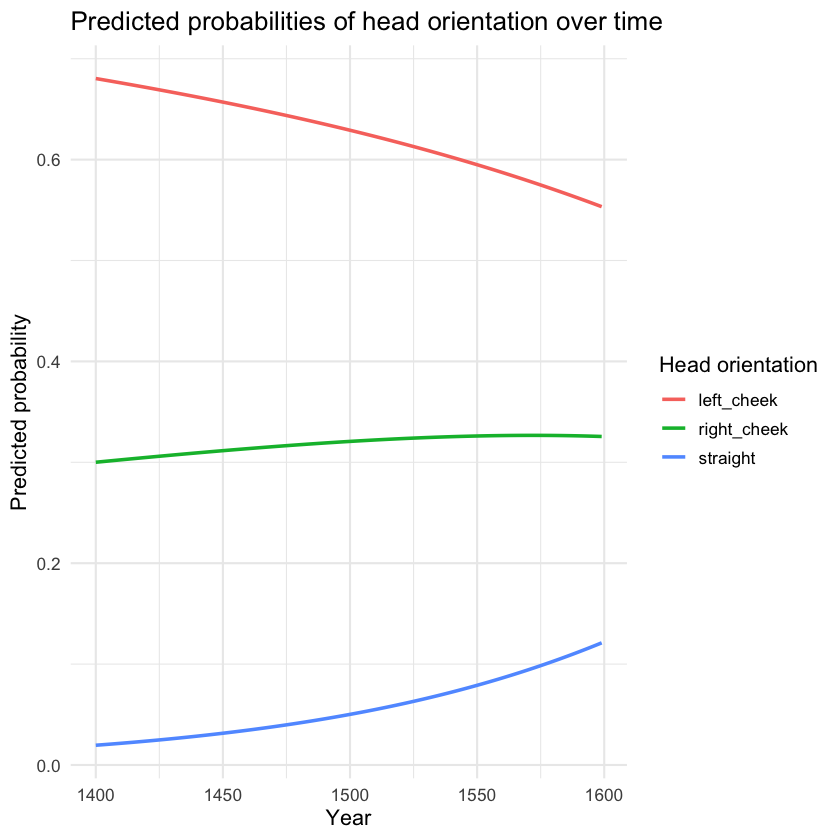

In [30]:
# Quick version: classify head orientation (left/right/straight, ±7.5° threshold) and run multinomial logistic regression for Renaissance left-cheek bias.

# 1) データ整形：Left/Right/Straight に分類（±7.5°閾値）
dat <- metadf %>% filter(Condition=='Renaissance', date<1600) %>%
  mutate(
    headdirect = case_when(
      headYaw >  7.5 ~ "left_cheek",
      headYaw < -7.5 ~ "right_cheek",
      TRUE           ~ "straight"
    ),
    headdirect = factor(headdirect, levels = c("left_cheek","right_cheek","straight")),
    date_sc = scale(date)[,1]   # 年代を標準化
  ) %>%
  filter(!is.na(headdirect), !is.na(date_sc))

# 2) 多項ロジスティック回帰（固定効果）
#    参照カテゴリは left_cheek（= Left Cheek Bias が基準）
m_mn <- multinom(headdirect ~ date_sc, data = dat, trace = FALSE)

summary(m_mn)
broom::tidy(m_mn, conf.int = TRUE, exponentiate = TRUE)  # 相対オッズ比で確認

# 3) 「Left Cheek Biasが年代とともに弱まるか？」の検定
#   → left を基準にした right/straight の相対オッズに対する date_sc の傾きが正なら
#     時代が進むほど「right or straight」相対比が増え、Left優位が弱まる解釈
#   emmeans でトレンド（傾き）を直接テスト
em_trend_right  <- emtrends(m_mn, ~ 1, var = "date_sc", mode = "latent", which = "right_cheek")
em_trend_straight <- emtrends(m_mn, ~ 1, var = "date_sc", mode = "latent", which = "straight")
em_trend_right
em_trend_straight

# 4) 予測確率の連続曲線を可視化（年代 vs 各カテゴリ確率）
grid <- tibble(
  date = seq(min(dat$date), max(dat$date), length.out = 200)
) %>%
  mutate(date_sc = (date - mean(dat$date, na.rm=TRUE))/sd(dat$date, na.rm=TRUE))

emm_curve <- emmeans(m_mn, ~ headdirect | date_sc, at = list(date_sc = grid$date_sc), type = "response")
plotdf <- as.data.frame(emm_curve) %>%
  mutate(date = grid$date[match(date_sc, grid$date_sc)])
ggplot(plotdf, aes(x = date, y = prob, color = headdirect)) +
  geom_line(size = 1) +
  scale_x_continuous(breaks=seq(1400,1600,50)) +
  # scale_y_continuous(labels = percent_format(accuracy = 1)) +
  labs(x = "Year", y = "Predicted probability", color = "Head orientation",
       title = "Predicted probabilities of head orientation over time") +
  theme_minimal(base_size = 13)

Sample size: 863 

Head Direction Distribution:

 left_cheek right_cheek    straight 
        524         279          60 

===== RESULTS TABLE =====
                    Outcome           Predictor Coefficient    SE      z
1 Right Cheek vs Left Cheek           Intercept      -0.630 0.074  -8.49
2 Right Cheek vs Left Cheek Date (standardized)       0.053 0.074   0.71
3    Straight vs Left Cheek           Intercept      -2.217 0.143 -15.53
4    Straight vs Left Cheek Date (standardized)       0.372 0.149   2.49
  p_value    OR          CI_95
1   <.001 0.533 [0.461, 0.616]
2   0.478 1.054  [0.911, 1.22]
3   <.001 0.109 [0.082, 0.144]
4   0.013 1.450 [1.082, 1.944]

===== MODEL FIT =====
       Statistic   Value
1 N observations  863.00
2   N parameters    4.00
3 Log-likelihood -733.11
4            AIC 1474.23
5            BIC 1493.27

===== CONFUSION MATRIX =====
             Predicted
Observed      left_cheek right_cheek straight
  left_cheek         524           0        0
  right_chee

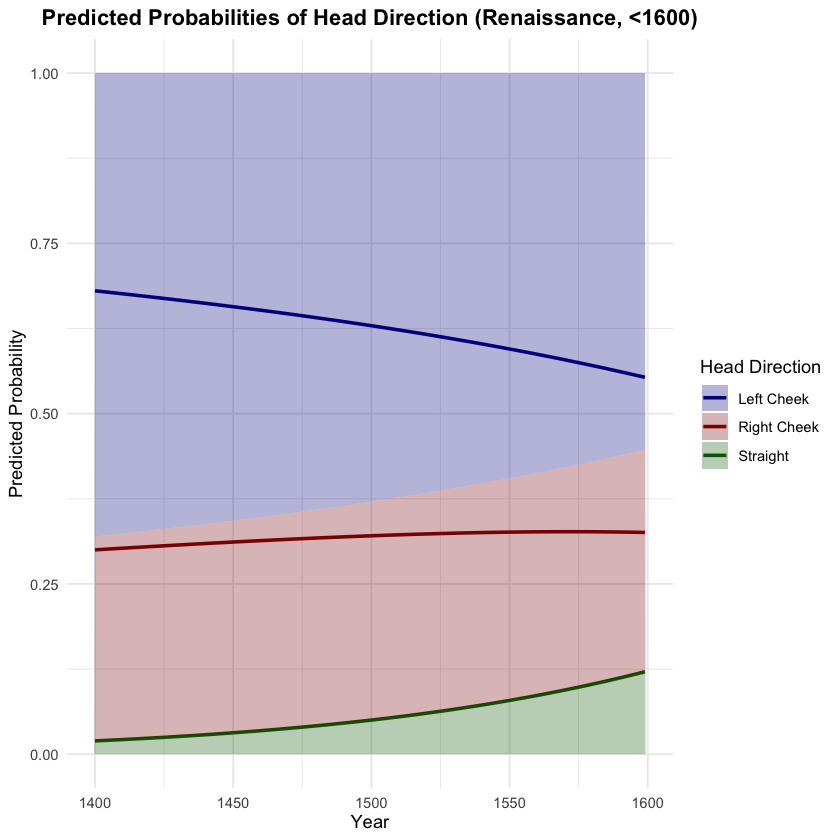

In [31]:
# Cleaner version: data preparation and multinomial logistic regression for Renaissance left-cheek bias; extract predicted probabilities over time.
library(nnet)
library(tidyverse)
library(magrittr)
library(broom)
library(xtable)
library(ggplot2)

# ==========================================
# 1. DATA PREPARATION
# ==========================================

dat <- metadf %>% 
  filter(Condition == 'Renaissance', date < 1600) %>%
  mutate(
    headdirect = case_when(
      headYaw >  7.5  ~ "left_cheek",
      headYaw < -7.5  ~ "right_cheek",
      TRUE            ~ "straight"
    ),
    headdirect = factor(headdirect, levels = c("left_cheek", "right_cheek", "straight")),
    date_sc = scale(date)[, 1]
  ) %>%
  filter(!is.na(headdirect), !is.na(date_sc))

cat("Sample size:", nrow(dat), "\n\n")
cat("Head Direction Distribution:\n")
print(table(dat$headdirect))

# ==========================================
# 2. FIT MULTINOMIAL LOGISTIC REGRESSION
# ==========================================

m_mn <- multinom(headdirect ~ date_sc, data = dat, trace = FALSE)

# ==========================================
# 3. EXTRACT RESULTS
# ==========================================

coef_mn <- coef(m_mn)
se_mn <- summary(m_mn)$standard.errors
z_values <- coef_mn / se_mn
p_values <- 2 * (1 - pnorm(abs(z_values)))
or_mn <- exp(coef_mn)
or_ci_lower <- exp(coef_mn - 1.96 * se_mn)
or_ci_upper <- exp(coef_mn + 1.96 * se_mn)

# ==========================================
# 4. COMPILE RESULTS TABLE
# ==========================================

results_table <- data.frame(
  Outcome = c(
    "Right Cheek vs Left Cheek",
    "Right Cheek vs Left Cheek",
    "Straight vs Left Cheek",
    "Straight vs Left Cheek"
  ),
  Predictor = c(
    "Intercept", "Date (standardized)",
    "Intercept", "Date (standardized)"
  ),
  Coefficient = c(
    round(coef_mn[1, 1], 3), round(coef_mn[1, 2], 3),
    round(coef_mn[2, 1], 3), round(coef_mn[2, 2], 3)
  ),
  SE = c(
    round(se_mn[1, 1], 3), round(se_mn[1, 2], 3),
    round(se_mn[2, 1], 3), round(se_mn[2, 2], 3)
  ),
  z = c(
    round(z_values[1, 1], 2), round(z_values[1, 2], 2),
    round(z_values[2, 1], 2), round(z_values[2, 2], 2)
  ),
  p_value = c(
    ifelse(p_values[1, 1] < 0.001, "<.001", round(p_values[1, 1], 3)),
    ifelse(p_values[1, 2] < 0.001, "<.001", round(p_values[1, 2], 3)),
    ifelse(p_values[2, 1] < 0.001, "<.001", round(p_values[2, 1], 3)),
    ifelse(p_values[2, 2] < 0.001, "<.001", round(p_values[2, 2], 3))
  ),
  OR = c(
    round(or_mn[1, 1], 3), round(or_mn[1, 2], 3),
    round(or_mn[2, 1], 3), round(or_mn[2, 2], 3)
  ),
  CI_95 = c(
    paste0("[", round(or_ci_lower[1, 1], 3), ", ", round(or_ci_upper[1, 1], 3), "]"),
    paste0("[", round(or_ci_lower[1, 2], 3), ", ", round(or_ci_upper[1, 2], 3), "]"),
    paste0("[", round(or_ci_lower[2, 1], 3), ", ", round(or_ci_upper[2, 1], 3), "]"),
    paste0("[", round(or_ci_lower[2, 2], 3), ", ", round(or_ci_upper[2, 2], 3), "]")
  )
)

cat("\n===== RESULTS TABLE =====\n")
print(results_table)

# ==========================================
# 5. MODEL FIT & DIAGNOSTICS
# ==========================================

predicted_class <- predict(m_mn, type = "class")
confusion_matrix <- table(Observed = dat$headdirect, Predicted = predicted_class)
accuracy <- sum(diag(confusion_matrix)) / sum(confusion_matrix)

model_fit <- data.frame(
  Statistic = c("N observations", "N parameters", "Log-likelihood", "AIC", "BIC"),
  Value = c(
    nrow(dat),
    length(coef(m_mn)),
    round(logLik(m_mn)[1], 2),
    round(AIC(m_mn), 2),
    round(BIC(m_mn), 2)
  )
)

cat("\n===== MODEL FIT =====\n")
print(model_fit)

cat("\n===== CONFUSION MATRIX =====\n")
print(confusion_matrix)

cat("\n===== OVERALL ACCURACY =====\n")
cat(round(accuracy, 3), "\n")

# ==========================================
# 6. PREDICTED PROBABILITIES
# ==========================================

date_range <- seq(min(dat$date_sc), max(dat$date_sc), length.out = 50)
pred_data <- data.frame(date_sc = date_range)
pred_probs <- predict(m_mn, pred_data, type = "probs")

pred_results <- pred_data %>%
  bind_cols(as.data.frame(pred_probs)) %>%
  mutate(
    date = mean(metadf$date[metadf$Condition == 'Renaissance' & metadf$date < 1600], na.rm = T) + 
           date_sc * sd(metadf$date[metadf$Condition == 'Renaissance' & metadf$date < 1600], na.rm = T)
  )

pred_long <- pred_results %>%
  pivot_longer(
    cols = c(left_cheek, right_cheek, straight),
    names_to = "head_direction",
    values_to = "probability"
  ) %>%
  mutate(head_direction = factor(head_direction, levels = c("left_cheek", "right_cheek", "straight")))

p <- ggplot(pred_long, aes(x = date, y = probability, color = head_direction, fill = head_direction)) +
  geom_line(size = 1) +
  geom_area(alpha = 0.3, position = "stack", linetype = 0) +
  scale_x_continuous(breaks = seq(1300, 1600, 50)) +
  scale_color_manual(
    values = c("left_cheek" = "darkblue", "right_cheek" = "darkred", "straight" = "darkgreen"),
    labels = c("left_cheek" = "Left Cheek", "right_cheek" = "Right Cheek", "straight" = "Straight")
  ) +
  scale_fill_manual(
    values = c("left_cheek" = "darkblue", "right_cheek" = "darkred", "straight" = "darkgreen"),
    labels = c("left_cheek" = "Left Cheek", "right_cheek" = "Right Cheek", "straight" = "Straight")
  ) +
  labs(
    title = "Predicted Probabilities of Head Direction (Renaissance, <1600)",
    x = "Year",
    y = "Predicted Probability",
    color = "Head Direction",
    fill = "Head Direction"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"))

print(p)

# ==========================================
# 7. GENERATE LATEX TABLES
# ==========================================

coef_table <- results_table %>% select(Outcome, Predictor, Coefficient, SE, z, p_value)
or_table <- results_table %>% select(Outcome, Predictor, OR, CI_95)
sample_char <- dat %>%
  group_by(headdirect) %>%
  summarise(n = n(), .groups = 'drop') %>%
  mutate(
    Percentage = round(n / nrow(dat) * 100, 1),
    headdirect = case_when(
      headdirect == "left_cheek" ~ "Left Cheek",
      headdirect == "right_cheek" ~ "Right Cheek",
      headdirect == "straight" ~ "Straight"
    )
  ) %>%
  rename("Head Direction" = headdirect, "N" = n, "%" = Percentage)

# ── Fixed Effects Table ──────────────────────────────
print(xtable(coef_table, caption = "Multinomial Logistic Regression: Log-Odds Coefficients (Renaissance, <1600)",
             label = "tab:multinomial_coef", digits = 3),
      include.rownames = FALSE, booktabs = TRUE, sanitize.text.function = identity,
     file = "result9_fixed_effects_left_cheek_R.tex")

print(xtable(or_table, caption = "Multinomial Logistic Regression: Odds Ratios with 95\\% CI (Renaissance, <1600)",
             label = "tab:multinomial_or", digits = 3),
      include.rownames = FALSE, booktabs = TRUE, sanitize.text.function = identity,
     file = "result9_odds_ratio_left_cheek_R.tex")

print(xtable(model_fit, caption = "Multinomial Model Fit Statistics (Renaissance, <1600)",
             label = "tab:multinomial_fit", digits = 2),
      include.rownames = FALSE, booktabs = TRUE)

print(xtable(sample_char, caption = "Sample Distribution by Head Direction (Renaissance, <1600)",
             label = "tab:sample_headdirection", digits = 1),
      include.rownames = FALSE, booktabs = TRUE)


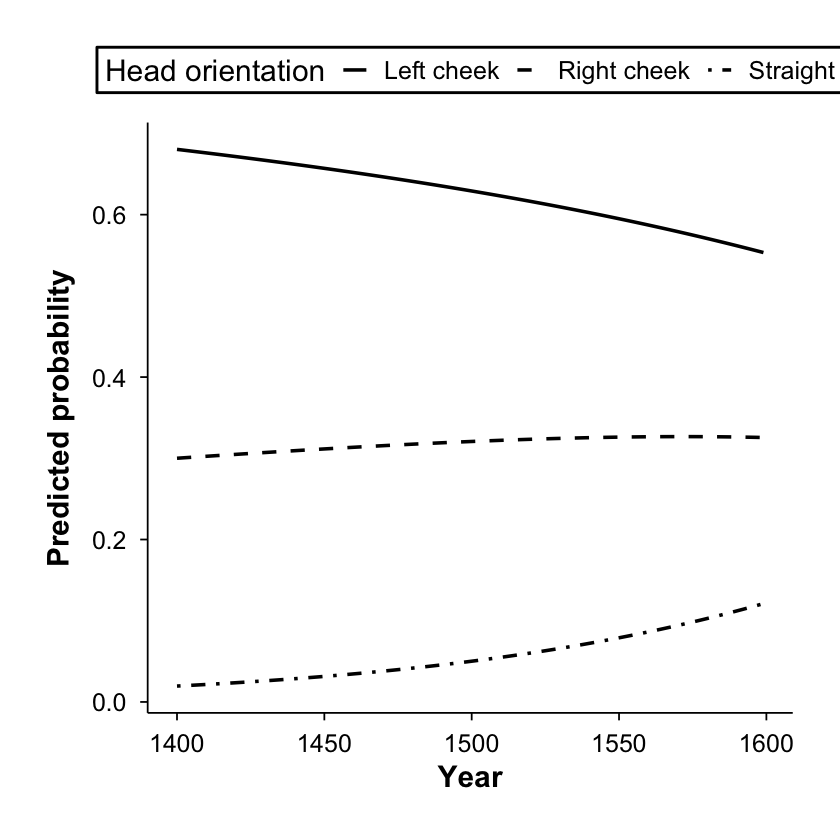

In [32]:
# Plot predicted probabilities of left-cheek, right-cheek, and straight orientations over time during the Renaissance.
(p <- ggplot(plotdf, aes(x = date, y = prob, linetype = headdirect)) +
  geom_line(size = 1, colour = "black") +
  scale_x_continuous(breaks = seq(1400, 1600, 50)) +
  scale_linetype_manual(
    values = c("solid", "dashed", "dotdash"),
    labels = c("Left cheek", "Right cheek", "Straight")
  ) +
  labs(
    x = "Year",
    y = "Predicted probability",
    linetype = "Head orientation"
  ))
# 
# ggsave('Cheek_Renai.png',p)

### popularity

In [33]:
# Quick version: fit mixed model predicting web hits from head orientation, sitter fame, and year in Renaissance portraits.

dat %>% lmer(log_hits~headdirect+scale(log_fame) + scale(date) + (1 |SCHOOL) + (1|AUTHOR),data=.) -> fit1
summary(fit1)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: log_hits ~ headdirect + scale(log_fame) + scale(date) + (1 |  
    SCHOOL) + (1 | AUTHOR)
   Data: .

REML criterion at convergence: 979

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.57790 -0.56121 -0.02134  0.60451  2.01459 

Random effects:
 Groups   Name        Variance Std.Dev.
 AUTHOR   (Intercept) 1.1302   1.0631  
 SCHOOL   (Intercept) 0.5369   0.7328  
 Residual             1.6252   1.2748  
Number of obs: 270, groups:  AUTHOR, 65; SCHOOL, 8

Fixed effects:
                       Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)             4.12253    0.35891   3.83238  11.486 0.000414 ***
headdirectright_cheek   0.04213    0.19892 256.24763   0.212 0.832453    
headdirectstraight      0.42809    0.31159 244.87798   1.374 0.170731    
scale(log_fame)         0.60146    0.09332 258.25007   6.445 5.63e-10 ***
scale(date)            -0.06463    0.15391

In [34]:
# Cleaner version: data preparation and model fitting for Renaissance head orientation vs. cultural prominence.
# ==========================================
# 1. DATA PREPARATION
# ==========================================

dat <- metadf %>% 
  filter(Condition == 'Renaissance', date < 1600) %>%
  mutate(
    headdirect = case_when(
      headYaw >  7.5  ~ "left_cheek",
      headYaw < -7.5  ~ "right_cheek",
      TRUE            ~ "straight"
    ),
    headdirect = factor(headdirect, levels = c("left_cheek", "right_cheek", "straight")),
    date_sc = scale(date)[, 1]
  ) %>%
  filter(!is.na(headdirect), !is.na(date_sc))

cat("Sample size:", nrow(dat), "\n\n")

# ==========================================
# 2. FIT MODEL
# ==========================================

dat %>% 
  lmer(
    log_hits ~ headdirect + scale(log_fame) + scale(date) + 
               (1 | SCHOOL) + (1 | AUTHOR),
    data = .
  ) -> fit1

# ==========================================
# 3. EXTRACT RESULTS
# ==========================================

fixed_summary <- summary(fit1)$coefficients %>%
  as.data.frame() %>%
  rownames_to_column("Predictor") %>%
  rename(Beta = Estimate, SE = `Std. Error`, df = df, t = `t value`, p = `Pr(>|t|)`)

ci_fit1 <- confint(fit1, method = "Wald") %>%
  as.data.frame() %>%
  rownames_to_column("Predictor") %>%
  rename(CI_lower = `2.5 %`, CI_upper = `97.5 %`) %>%
  filter(!grepl("\\.|sigma", Predictor))

beta_estimates <- summary(fit1)$coefficients[, "Estimate"]
beta_std <- c(NA, NA, NA, beta_estimates[4], beta_estimates[5])

var_comp <- VarCorr(fit1)
var_school <- as.numeric(var_comp$SCHOOL[1, 1])
var_author <- as.numeric(var_comp$AUTHOR[1, 1])
var_residual <- attr(var_comp, "sc")^2
var_total <- var_school + var_author + var_residual

random_table <- data.frame(
  Group = c("School", "Author", "Residual"),
  Variance = c(var_school, var_author, var_residual),
  SD = c(sqrt(var_school), sqrt(var_author), sqrt(var_residual)),
  ICC = c(round(var_school / var_total, 3), round(var_author / var_total, 3), NA)
) %>%
  mutate(across(where(is.numeric), ~round(.x, 3)))

# ==========================================
# 4. COMPILE RESULTS
# ==========================================

results_fixed <- fixed_summary %>%
  left_join(ci_fit1, by = "Predictor") %>%
  mutate(
    Predictor = c("(Intercept)", "Head Direction: Right Cheek", "Head Direction: Straight",
                  "Log Fame (z-score)", "Date (z-score)"),
    `95% CI` = paste0("[", round(CI_lower, 3), ", ", round(CI_upper, 3), "]"),
    Beta = round(Beta, 3), SE = round(SE, 3), t = round(t, 2), df = round(df, 2),
    p = ifelse(p < 0.001, "<.001", round(p, 3)), Beta_std = round(beta_std, 3)
  ) %>%
  select(Predictor, Beta, SE, `95% CI`, t, df, p, Beta_std)

cat("\n===== FIXED EFFECTS =====\n")
print(results_fixed)
cat("\n===== RANDOM EFFECTS =====\n")
print(random_table)

# ==========================================
# 5. DIAGNOSTICS
# ==========================================

r2_fit1 <- performance::r2(fit1)
cat("\n===== DIAGNOSTICS =====\n")
print(r2_fit1)

# ==========================================
# 6. EFFECT SIZES
# ==========================================

left_cheek_effect  <- beta_estimates[1]
right_cheek_effect <- beta_estimates[1] + beta_estimates[2]
straight_effect    <- beta_estimates[1] + beta_estimates[3]

cat("\nEstimated Effects by Head Direction:\n")
cat("Left Cheek:  ", round(left_cheek_effect, 3), "\n")
cat("Right Cheek: ", round(right_cheek_effect, 3), "\n")
cat("Straight:    ", round(straight_effect, 3), "\n")

# ==========================================
# 9. LATEX TABLES
# ==========================================

# BUG FIX: second print now uses append = TRUE so both tables go into the same file
# without the second overwriting the first.

# Fixed effects table
print(
  xtable(results_fixed,
         caption = "Fixed Effects Estimates: Head Direction Model (Renaissance, <1600)",
         label   = "tab:fixed_effects_headdirection",
         digits  = 3),
  include.rownames        = FALSE,
  booktabs                = TRUE,
  sanitize.text.function  = identity,
  file                    = "result10_odds_ratio_left_cheek_R_popularity.tex"
)

# Random effects table — appended to the same file
print(
  xtable(random_table,
         caption = "Random Effects Variance Components (Head Direction Model, <1600)",
         label   = "tab:random_effects_headdirection",
         digits  = 3),
  include.rownames        = FALSE,
  booktabs                = TRUE,
  sanitize.text.function  = identity,
  file                    = "result10_odds_ratio_left_cheek_R_popularity_random.tex",
  append                  = TRUE
)

Sample size: 863 


===== FIXED EFFECTS =====
                    Predictor   Beta    SE          95% CI     t     df     p
1                 (Intercept)  4.123 0.359  [3.419, 4.826] 11.49   3.83 <.001
2 Head Direction: Right Cheek  0.042 0.199 [-0.348, 0.432]  0.21 256.25 0.832
3    Head Direction: Straight  0.428 0.312 [-0.183, 1.039]  1.37 244.88 0.171
4          Log Fame (z-score)  0.601 0.093  [0.419, 0.784]  6.45 258.25 <.001
5              Date (z-score) -0.065 0.154 [-0.366, 0.237] -0.42  85.85 0.676
  Beta_std
1       NA
2       NA
3       NA
4    0.601
5   -0.065

===== RANDOM EFFECTS =====
     Group Variance    SD   ICC
1   School    0.537 0.733 0.163
2   Author    1.130 1.063 0.343
3 Residual    1.625 1.275    NA

===== DIAGNOSTICS =====
# R2 for Mixed Models

  Conditional R2: 0.556
     Marginal R2: 0.101

Estimated Effects by Head Direction:
Left Cheek:   4.123 
Right Cheek:  4.165 
Straight:     4.551 


### Left Cheek Bias becomes weaker after the Renaissance

Call:
multinom(formula = headdirect ~ date_sc, data = dat, trace = FALSE)

Coefficients:
              (Intercept)     date_sc
right_cheek  0.0009114029 -0.02497919
straight    -0.8189987732  0.25759160

Std. Errors:
            (Intercept)    date_sc
right_cheek  0.06514068 0.06505613
straight     0.08394382 0.08492033

Residual Deviance: 2403.173 
AIC: 2411.173 

y.level,term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
right_cheek,(Intercept),1.0009118,0.06514068,0.0139913,9.888369e-01,0.8809433,1.1372178
right_cheek,date_sc,0.9753302,0.06505613,-0.3839637,7.010053e-01,0.8585702,1.1079688
straight,(Intercept),0.4408728,0.08394382,-9.7565102,1.730062e-22,0.3739902,0.5197165
straight,date_sc,1.2938103,0.08492033,3.0333325,2.418689e-03,1.0954342,1.5281111


 1       date_sc.trend SE df lower.CL upper.CL
 overall             0  0  4        0        0

Results are averaged over the levels of: headdirect 
Confidence level used: 0.95 

 1       date_sc.trend SE df lower.CL upper.CL
 overall             0  0  4        0        0

Results are averaged over the levels of: headdirect 
Confidence level used: 0.95 


===== RESULTS TABLE =====
                    Outcome           Predictor Coefficient    SE     z p_value
1 Right Cheek vs Left Cheek           Intercept       0.001 0.065  0.01   0.989
2 Right Cheek vs Left Cheek Date (standardized)      -0.025 0.065 -0.38   0.701
3    Straight vs Left Cheek           Intercept      -0.819 0.084 -9.76   <.001
4    Straight vs Left Cheek Date (standardized)       0.258 0.085  3.03   0.002
     OR          CI_95
1 1.001 [0.881, 1.137]
2 0.975 [0.859, 1.108]
3 0.441  [0.374, 0.52]
4 1.294 [1.095, 1.528]

===== MODEL FIT =====
       Statistic    Value
1 N observations  1158.00
2   N parameters     4.00
3 Log-likelihood -1201.59
4            AIC  2411.17
5            BIC  2431.39

===== CONFUSION MATRIX =====
             Predicted
Observed      left_cheek right_cheek straight
  left_cheek         209         263        0
  right_cheek        210         263        0
  straight           111         102        0

===== OVERALL ACCURACY =====
0.408 
% lat

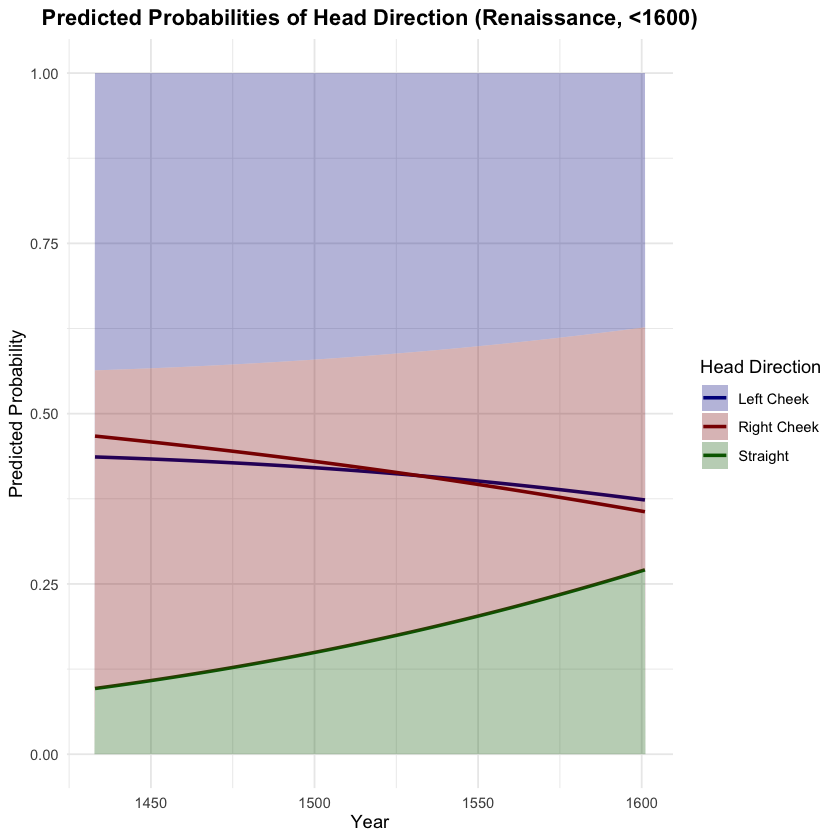

In [35]:
# Classify post-Renaissance head orientations and run multinomial logistic regression to test whether left-cheek bias weakens over time.

# 1) データ整形：Left/Right/Straight に分類（±7.5°閾値）
dat <- metadf %>% filter(Condition=='Post_Renaissance') %>%
  mutate(
    headdirect = case_when(
      headYaw >  7.5 ~ "left_cheek",
      headYaw < -7.5 ~ "right_cheek",
      TRUE           ~ "straight"
    ),
    headdirect = factor(headdirect, levels = c("left_cheek","right_cheek","straight")),
    date_sc = scale(date)[,1]   # 年代を標準化
  ) %>%
  filter(!is.na(headdirect), !is.na(date_sc))

# 2) 多項ロジスティック回帰（固定効果）
#    参照カテゴリは left_cheek（= Left Cheek Bias が基準）
m_mn <- multinom(headdirect ~ date_sc, data = dat, trace = FALSE)

summary(m_mn)
broom::tidy(m_mn, conf.int = TRUE, exponentiate = TRUE)  # 相対オッズ比で確認

# 3) 「Left Cheek Biasが年代とともに弱まるか？」の検定
#   → left を基準にした right/straight の相対オッズに対する date_sc の傾きが正なら
#     時代が進むほど「right or straight」相対比が増え、Left優位が弱まる解釈
#   emmeans でトレンド（傾き）を直接テスト
em_trend_right  <- emtrends(m_mn, ~ 1, var = "date_sc", mode = "latent", which = "right_cheek")
em_trend_straight <- emtrends(m_mn, ~ 1, var = "date_sc", mode = "latent", which = "straight")
em_trend_right
em_trend_straight


# ==========================================
# 3. EXTRACT RESULTS
# ==========================================

coef_mn <- coef(m_mn)
se_mn <- summary(m_mn)$standard.errors
z_values <- coef_mn / se_mn
p_values <- 2 * (1 - pnorm(abs(z_values)))
or_mn <- exp(coef_mn)
or_ci_lower <- exp(coef_mn - 1.96 * se_mn)
or_ci_upper <- exp(coef_mn + 1.96 * se_mn)

# ==========================================
# 4. COMPILE RESULTS TABLE
# ==========================================

results_table <- data.frame(
  Outcome = c(
    "Right Cheek vs Left Cheek",
    "Right Cheek vs Left Cheek",
    "Straight vs Left Cheek",
    "Straight vs Left Cheek"
  ),
  Predictor = c(
    "Intercept", "Date (standardized)",
    "Intercept", "Date (standardized)"
  ),
  Coefficient = c(
    round(coef_mn[1, 1], 3), round(coef_mn[1, 2], 3),
    round(coef_mn[2, 1], 3), round(coef_mn[2, 2], 3)
  ),
  SE = c(
    round(se_mn[1, 1], 3), round(se_mn[1, 2], 3),
    round(se_mn[2, 1], 3), round(se_mn[2, 2], 3)
  ),
  z = c(
    round(z_values[1, 1], 2), round(z_values[1, 2], 2),
    round(z_values[2, 1], 2), round(z_values[2, 2], 2)
  ),
  p_value = c(
    ifelse(p_values[1, 1] < 0.001, "<.001", round(p_values[1, 1], 3)),
    ifelse(p_values[1, 2] < 0.001, "<.001", round(p_values[1, 2], 3)),
    ifelse(p_values[2, 1] < 0.001, "<.001", round(p_values[2, 1], 3)),
    ifelse(p_values[2, 2] < 0.001, "<.001", round(p_values[2, 2], 3))
  ),
  OR = c(
    round(or_mn[1, 1], 3), round(or_mn[1, 2], 3),
    round(or_mn[2, 1], 3), round(or_mn[2, 2], 3)
  ),
  CI_95 = c(
    paste0("[", round(or_ci_lower[1, 1], 3), ", ", round(or_ci_upper[1, 1], 3), "]"),
    paste0("[", round(or_ci_lower[1, 2], 3), ", ", round(or_ci_upper[1, 2], 3), "]"),
    paste0("[", round(or_ci_lower[2, 1], 3), ", ", round(or_ci_upper[2, 1], 3), "]"),
    paste0("[", round(or_ci_lower[2, 2], 3), ", ", round(or_ci_upper[2, 2], 3), "]")
  )
)

cat("\n===== RESULTS TABLE =====\n")
print(results_table)

# ==========================================
# 5. MODEL FIT & DIAGNOSTICS
# ==========================================

predicted_class <- predict(m_mn, type = "class")
confusion_matrix <- table(Observed = dat$headdirect, Predicted = predicted_class)
accuracy <- sum(diag(confusion_matrix)) / sum(confusion_matrix)

model_fit <- data.frame(
  Statistic = c("N observations", "N parameters", "Log-likelihood", "AIC", "BIC"),
  Value = c(
    nrow(dat),
    length(coef(m_mn)),
    round(logLik(m_mn)[1], 2),
    round(AIC(m_mn), 2),
    round(BIC(m_mn), 2)
  )
)

cat("\n===== MODEL FIT =====\n")
print(model_fit)

cat("\n===== CONFUSION MATRIX =====\n")
print(confusion_matrix)

cat("\n===== OVERALL ACCURACY =====\n")
cat(round(accuracy, 3), "\n")

# ==========================================
# 6. PREDICTED PROBABILITIES
# ==========================================

date_range <- seq(min(dat$date_sc), max(dat$date_sc), length.out = 50)
pred_data <- data.frame(date_sc = date_range)
pred_probs <- predict(m_mn, pred_data, type = "probs")

pred_results <- pred_data %>%
  bind_cols(as.data.frame(pred_probs)) %>%
  mutate(
    date = mean(metadf$date[metadf$Condition == 'Renaissance' & metadf$date < 1600], na.rm = T) + 
           date_sc * sd(metadf$date[metadf$Condition == 'Renaissance' & metadf$date < 1600], na.rm = T)
  )

pred_long <- pred_results %>%
  pivot_longer(
    cols = c(left_cheek, right_cheek, straight),
    names_to = "head_direction",
    values_to = "probability"
  ) %>%
  mutate(head_direction = factor(head_direction, levels = c("left_cheek", "right_cheek", "straight")))

p <- ggplot(pred_long, aes(x = date, y = probability, color = head_direction, fill = head_direction)) +
  geom_line(size = 1) +
  geom_area(alpha = 0.3, position = "stack", linetype = 0) +
  scale_x_continuous(breaks = seq(1300, 1600, 50)) +
  scale_color_manual(
    values = c("left_cheek" = "darkblue", "right_cheek" = "darkred", "straight" = "darkgreen"),
    labels = c("left_cheek" = "Left Cheek", "right_cheek" = "Right Cheek", "straight" = "Straight")
  ) +
  scale_fill_manual(
    values = c("left_cheek" = "darkblue", "right_cheek" = "darkred", "straight" = "darkgreen"),
    labels = c("left_cheek" = "Left Cheek", "right_cheek" = "Right Cheek", "straight" = "Straight")
  ) +
  labs(
    title = "Predicted Probabilities of Head Direction (Renaissance, <1600)",
    x = "Year",
    y = "Predicted Probability",
    color = "Head Direction",
    fill = "Head Direction"
  ) +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"))

print(p)

# ==========================================
# 7. GENERATE LATEX TABLES
# ==========================================

coef_table <- results_table %>% select(Outcome, Predictor, Coefficient, SE, z, p_value)
or_table <- results_table %>% select(Outcome, Predictor, OR, CI_95)
sample_char <- dat %>%
  group_by(headdirect) %>%
  summarise(n = n(), .groups = 'drop') %>%
  mutate(
    Percentage = round(n / nrow(dat) * 100, 1),
    headdirect = case_when(
      headdirect == "left_cheek" ~ "Left Cheek",
      headdirect == "right_cheek" ~ "Right Cheek",
      headdirect == "straight" ~ "Straight"
    )
  ) %>%
  rename("Head Direction" = headdirect, "N" = n, "%" = Percentage)

# ── Fixed Effects Table ──────────────────────────────
print(xtable(coef_table, caption = "Multinomial Logistic Regression: Log-Odds Coefficients (Renaissance, <1600)",
             label = "tab:multinomial_coef", digits = 3),
      include.rownames = FALSE, booktabs = TRUE, sanitize.text.function = identity,
     file = "result9_fixed_effects_left_cheek_R.tex")

print(xtable(or_table, caption = "Multinomial Logistic Regression: Odds Ratios with 95\\% CI (Renaissance, <1600)",
             label = "tab:multinomial_or", digits = 3),
      include.rownames = FALSE, booktabs = TRUE, sanitize.text.function = identity,
     file = "result9_odds_ratio_left_cheek_R.tex")

print(xtable(model_fit, caption = "Multinomial Model Fit Statistics (Renaissance, <1600)",
             label = "tab:multinomial_fit", digits = 2),
      include.rownames = FALSE, booktabs = TRUE)

print(xtable(sample_char, caption = "Sample Distribution by Head Direction (Renaissance, <1600)",
             label = "tab:sample_headdirection", digits = 1),
      include.rownames = FALSE, booktabs = TRUE)

Saving 6.67 x 6.67 in image


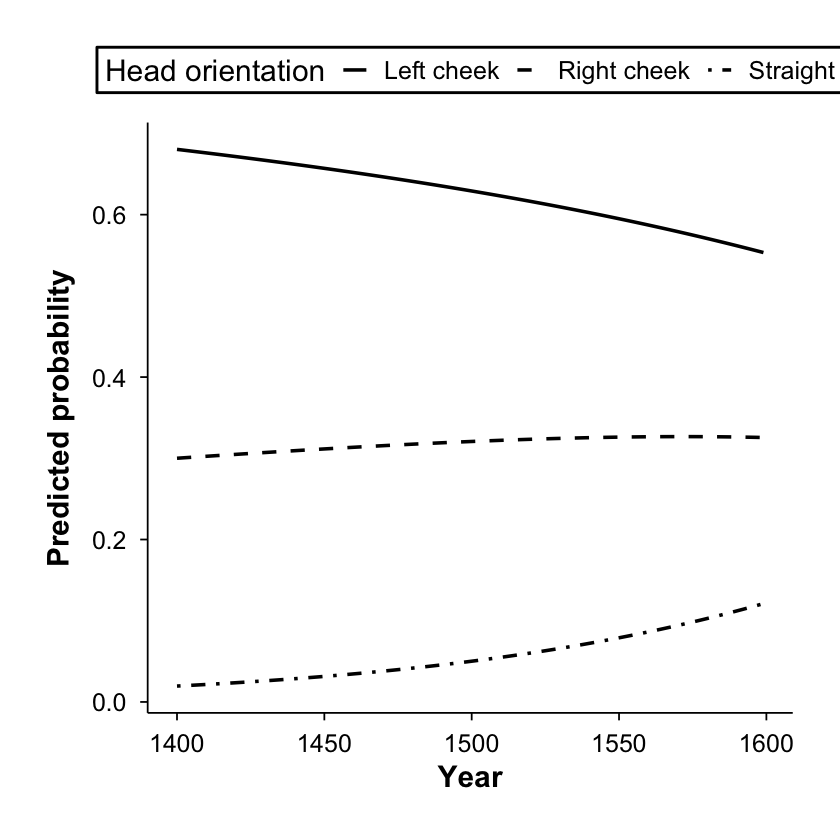

In [36]:
# Plot predicted probabilities of head orientations over time in the post-Renaissance period.
(p <- ggplot(plotdf, aes(x = date, y = prob, linetype = headdirect)) +
  geom_line(size = 1, colour = "black") +
  scale_linetype_manual(
    values = c("solid", "dashed", "dotdash"),
    labels = c("Left cheek", "Right cheek", "Straight")
  ) +
  labs(
    x = "Year",
    y = "Predicted probability",
    linetype = "Head orientation",
  ))
ggsave('Cheek_Post_Renai.png',p)

### Popularity

In [37]:
# Fit mixed model predicting web hits from head orientation, sitter fame, and year in post-Renaissance portraits.
dat %>% lmer(log_hits~headdirect+scale(log_fame) + scale(date) + (1 |SCHOOL) + (1|AUTHOR),data=.) -> fit1
summary(fit1)

# ==========================================
# 3. EXTRACT RESULTS
# ==========================================

fixed_summary <- summary(fit1)$coefficients %>%
  as.data.frame() %>%
  rownames_to_column("Predictor") %>%
  rename(Beta = Estimate, SE = `Std. Error`, df = df, t = `t value`, p = `Pr(>|t|)`)

ci_fit1 <- confint(fit1, method = "Wald") %>%
  as.data.frame() %>%
  rownames_to_column("Predictor") %>%
  rename(CI_lower = `2.5 %`, CI_upper = `97.5 %`) %>%
  filter(!grepl("\\.|sigma", Predictor))

beta_estimates <- summary(fit1)$coefficients[, "Estimate"]
beta_std <- c(NA, NA, NA, beta_estimates[4], beta_estimates[5])

var_comp <- VarCorr(fit1)
var_school <- as.numeric(var_comp$SCHOOL[1, 1])
var_author <- as.numeric(var_comp$AUTHOR[1, 1])
var_residual <- attr(var_comp, "sc")^2
var_total <- var_school + var_author + var_residual

random_table <- data.frame(
  Group = c("School", "Author", "Residual"),
  Variance = c(var_school, var_author, var_residual),
  SD = c(sqrt(var_school), sqrt(var_author), sqrt(var_residual)),
  ICC = c(round(var_school / var_total, 3), round(var_author / var_total, 3), NA)
) %>%
  mutate(across(where(is.numeric), ~round(.x, 3)))

# ==========================================
# 4. COMPILE RESULTS
# ==========================================

results_fixed <- fixed_summary %>%
  left_join(ci_fit1, by = "Predictor") %>%
  mutate(
    Predictor = c("(Intercept)", "Head Direction: Right Cheek", "Head Direction: Straight",
                  "Log Fame (z-score)", "Date (z-score)"),
    `95% CI` = paste0("[", round(CI_lower, 3), ", ", round(CI_upper, 3), "]"),
    Beta = round(Beta, 3), SE = round(SE, 3), t = round(t, 2), df = round(df, 2),
    p = ifelse(p < 0.001, "<.001", round(p, 3)), Beta_std = round(beta_std, 3)
  ) %>%
  select(Predictor, Beta, SE, `95% CI`, t, df, p, Beta_std)

cat("\n===== FIXED EFFECTS =====\n")
print(results_fixed)
cat("\n===== RANDOM EFFECTS =====\n")
print(random_table)

# ==========================================
# 5. DIAGNOSTICS
# ==========================================

r2_fit1 <- performance::r2(fit1)
cat("\n===== DIAGNOSTICS =====\n")
print(r2_fit1)

# ==========================================
# 6. EFFECT SIZES
# ==========================================

left_cheek_effect  <- beta_estimates[1]
right_cheek_effect <- beta_estimates[1] + beta_estimates[2]
straight_effect    <- beta_estimates[1] + beta_estimates[3]

cat("\nEstimated Effects by Head Direction:\n")
cat("Left Cheek:  ", round(left_cheek_effect, 3), "\n")
cat("Right Cheek: ", round(right_cheek_effect, 3), "\n")
cat("Straight:    ", round(straight_effect, 3), "\n")

# ==========================================
# 9. LATEX TABLES
# ==========================================

# BUG FIX: second print now uses append = TRUE so both tables go into the same file
# without the second overwriting the first.

# Fixed effects table
print(
  xtable(results_fixed,
         caption = "Fixed Effects Estimates: Head Direction Model (Renaissance, <1600)",
         label   = "tab:fixed_effects_headdirection",
         digits  = 3),
  include.rownames        = FALSE,
  booktabs                = TRUE,
  sanitize.text.function  = identity,
  file                    = "result10_odds_ratio_left_cheek_R_popularity.tex"
)

# Random effects table — appended to the same file
print(
  xtable(random_table,
         caption = "Random Effects Variance Components (Head Direction Model, <1600)",
         label   = "tab:random_effects_headdirection",
         digits  = 3),
  include.rownames        = FALSE,
  booktabs                = TRUE,
  sanitize.text.function  = identity,
  file                    = "result10_odds_ratio_left_cheek_R_popularity_random.tex",
  append                  = TRUE
)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: log_hits ~ headdirect + scale(log_fame) + scale(date) + (1 |  
    SCHOOL) + (1 | AUTHOR)
   Data: .

REML criterion at convergence: 1156.8

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.8249 -0.6425 -0.0506  0.5737  3.3361 

Random effects:
 Groups   Name        Variance Std.Dev.
 AUTHOR   (Intercept) 0.4583   0.677   
 SCHOOL   (Intercept) 1.5064   1.227   
 Residual             3.5091   1.873   
Number of obs: 270, groups:  AUTHOR, 132; SCHOOL, 16

Fixed effects:
                        Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)             3.838367   0.401155  15.205373   9.568 7.91e-08 ***
headdirectright_cheek   0.005981   0.267275 253.006312   0.022   0.9822    
headdirectstraight     -0.088205   0.363275 251.827069  -0.243   0.8084    
scale(log_fame)         0.655657   0.126921 258.950779   5.166 4.78e-07 ***
scale(date)             0.312865   0.


===== FIXED EFFECTS =====
                    Predictor   Beta    SE          95% CI     t     df     p
1                 (Intercept)  3.838 0.401  [3.052, 4.625]  9.57  15.21 <.001
2 Head Direction: Right Cheek  0.006 0.267  [-0.518, 0.53]  0.02 253.01 0.982
3    Head Direction: Straight -0.088 0.363   [-0.8, 0.624] -0.24 251.83 0.808
4          Log Fame (z-score)  0.656 0.127  [0.407, 0.904]  5.17 258.95 <.001
5              Date (z-score)  0.313 0.163 [-0.006, 0.632]  1.92  79.50 0.058
  Beta_std
1       NA
2       NA
3       NA
4    0.656
5    0.313

===== RANDOM EFFECTS =====
     Group Variance    SD   ICC
1   School    1.506 1.227 0.275
2   Author    0.458 0.677 0.084
3 Residual    3.509 1.873    NA

===== DIAGNOSTICS =====
# R2 for Mixed Models

  Conditional R2: 0.409
     Marginal R2: 0.079

Estimated Effects by Head Direction:
Left Cheek:   3.838 
Right Cheek:  3.844 
Straight:     3.75 


## Study 5: Ukiyo-e

In [38]:
# Load ukiyo-e (actor prints and bijin-ga) dataset and inspect structure.
ukiyo <- read.csv('metafile.csv')
glimpse(ukiyo)

Rows: 154
Columns: 34
$ X             <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 1…
$ confidence    <dbl> 0.525, 0.875, 0.875, 0.875, 0.975, 0.775, 0.025, 0.875, …
$ headYaw       <dbl> 25.668509, 43.716680, 19.251382, 28.304115, 27.960340, -…
$ headPitch     <dbl> 11.688339, 19.652452, 11.344564, 18.964903, 42.226990, 1…
$ gazeYaw       <dbl> -28.934369, -20.683776, -20.855664, -26.126875, -23.2620…
$ gazePitch     <dbl> 23.7204527, 19.5378608, 12.5477757, 26.3560586, 39.53408…
$ filename      <chr> "arcBK01-0042_36(P)", "arcBK01-0042_73", "arcBK01-0042_7…
$ ACNo.         <chr> "arcBK01-0042_36(P)", "arcBK01-0042_73", "arcBK01-0042_7…
$ 画題等        <chr> "", "「忠孝武勇伝」", "", "「武道名誉伝」", "「堂しま救入船」", "「色競九重錦」", "",…
$ 画題２        <chr> "", "「三七のぶ孝」", "", "「仁木だん正」", "「かまくらや五郎八　三枡源之助」", "「おりう」…
$ 役名.代.役者  <chr> "", "", "", "", "", "", "", "", "", "", "", "", "", "芸妓〈…
$ 版元文字      <chr> "", "", "", "", "", "", "", "", "", "", "", "若、芝神明前、若与板"…
$ 版元1         <chr> "", "", "", "

### Eye gaze

n
<int>
154


n
<int>
109



Call:
lm(formula = gaze_cen ~ year, data = .)

Residuals:
    Min      1Q  Median      3Q     Max 
-22.960  -8.202   1.520   7.232  30.804 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)
(Intercept)  82.39675  125.76314   0.655    0.515
year         -0.03070    0.06765  -0.454    0.651

Residual standard error: 11.26 on 64 degrees of freedom
  (42 observations deleted due to missingness)
Multiple R-squared:  0.003208,	Adjusted R-squared:  -0.01237 
F-statistic: 0.2059 on 1 and 64 DF,  p-value: 0.6515


Warning message:
“Removed 42 rows containing non-finite outside the scale range
(`stat_summary()`).”
Saving 6.67 x 6.67 in image
Warning message:
“Removed 42 rows containing non-finite outside the scale range
(`stat_summary()`).”


    Predictor        Beta           SE          t         p
1 (Intercept) 82.39675251 125.76313849  0.6551741 0.5147038
2        year -0.03070099   0.06765126 -0.4538125 0.6514990
    Predictor     CI_lower    CI_upper
1 (Intercept) -168.8439987 333.6375037
2        year   -0.1658499   0.1044479

===== FIXED EFFECTS (Ukiyo-e Gaze ~ Year) =====
    Predictor   Beta      SE              95% CI     t     p Beta_std
1 (Intercept) 82.397 125.763 [-168.844, 333.638]  0.66 0.515       NA
2        Year -0.031   0.068     [-0.166, 0.104] -0.45 0.651   -0.055

===== MODEL FIT =====
       Statistic   Value
1 N observations 108.000
2      R-squared   0.003
3 Adj. R-squared  -0.012
4    F statistic   0.210
5            AIC 510.900
6            BIC 517.470

===== LATEX: Fixed Effects Table =====
% latex table generated in R 4.5.2 by xtable 1.8-8 package
% Wed Mar 18 19:45:20 2026
\begin{table}[ht]
\centering
\begin{tabular}{lrrlrrr}
  \toprule
Predictor & Beta & SE & 95% CI & t & p & Beta_std \\ 
 

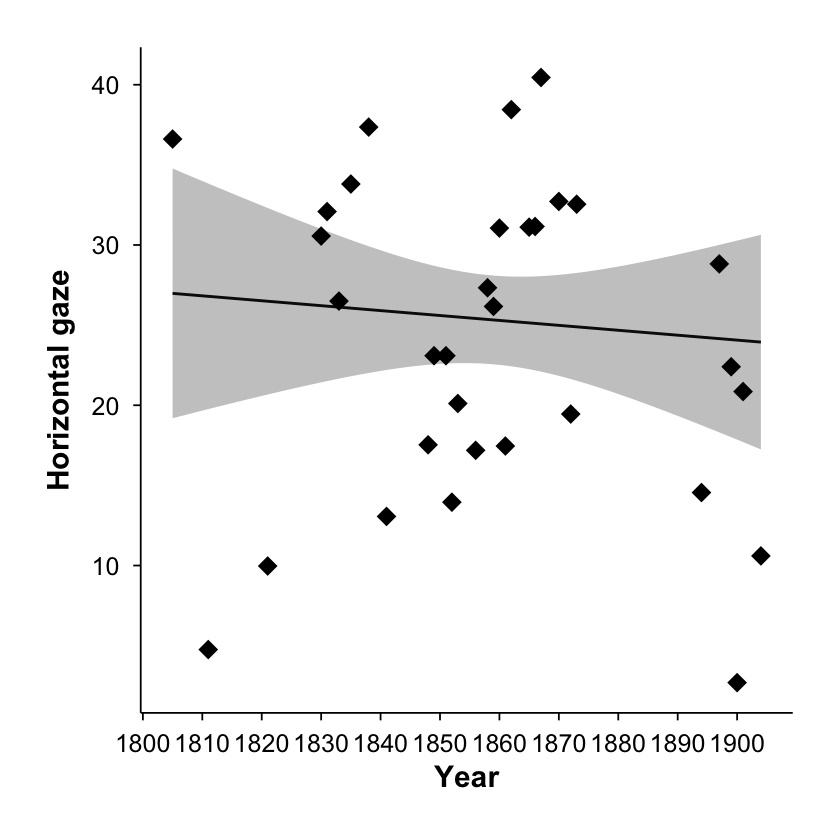

In [39]:
# Filter ukiyo-e data by quality thresholds; fit linear model predicting absolute gaze deviation from production year; plot predicted trend.
# head(metadf)
ukiyo %>% filter(headPitch<90,headPitch>-90,confidence>.800) %>% mutate(gaze_cen=abs(gazeYaw)) -> ukiyo_cen
ukiyo %>% summarise(n=n())
ukiyo %>% filter(confidence>.800) %>% summarise(n=n())
ukiyo_cen %>% lm(gaze_cen~year,data=.) -> fit1
fit1 %>% summary()

glm_p <- ggpredict(fit1, terms = c("year"))

(p <-ggplot() + 
     geom_line(data = glm_p, aes(x = x, y = predicted), show.legend = F) + 
     scale_x_continuous(breaks=seq(1800,1950,10)) +
     geom_ribbon(data = glm_p, aes(x = x, ymin = conf.low, ymax = conf.high), alpha = 0.3,show.legend = F) +
     stat_summary(data = filter(ukiyo_cen,headPitch<90,headPitch>-90), aes(x = year, y = gaze_cen), fun= mean, geom="point", size = 5, shape = 18, position = position_dodge(width = .75)) +
     ylab("Horizontal gaze") + xlab("Year"))
ggsave("Gaze_Shift_Ukiyo.png",p)

# ==========================================
# RESULTS EXTRACTION & LATEX OUTPUT
# ==========================================

# Extract fixed effects from lm summary (no df column for plain lm — unlike lmerTest)
fixed_summary <- summary(fit1)$coefficients %>%
  as.data.frame() %>%
  rownames_to_column("Predictor") %>%
  rename(
    Beta = Estimate,
    SE   = `Std. Error`,
    t    = `t value`,
    p    = `Pr(>|t|)`
  )

print(fixed_summary)

# 95% CI using default t-distribution method (valid for lm; "Wald" is lmerTest-only)
ci_fit1 <- confint(fit1) %>%
  as.data.frame() %>%
  rownames_to_column("Predictor") %>%
  rename(CI_lower = `2.5 %`, CI_upper = `97.5 %`)

print(ci_fit1)

# Standardized Beta = beta * (SD_predictor / SD_outcome)
sd_outcome <- sd(ukiyo_cen$gaze_cen, na.rm = TRUE)
sd_year    <- sd(ukiyo_cen$year,     na.rm = TRUE)

beta_estimates <- summary(fit1)$coefficients[, "Estimate"]

beta_std <- c(
  NA,                                              # Intercept
  beta_estimates[2] * (sd_year / sd_outcome)       # year
)

# Compile results table
results_fixed <- fixed_summary %>%
  left_join(ci_fit1, by = "Predictor") %>%
  mutate(
    Predictor = c("(Intercept)", "Year"),
    `95% CI`  = paste0("[", round(CI_lower, 3), ", ", round(CI_upper, 3), "]"),
    Beta      = round(Beta, 3),
    SE        = round(SE, 3),
    t         = round(t, 2),
    p         = ifelse(p < 0.001, "<.001", round(p, 3)),
    Beta_std  = round(beta_std, 3)
  ) %>%
  select(Predictor, Beta, SE, `95% CI`, t, p, Beta_std)

cat("\n===== FIXED EFFECTS (Ukiyo-e Gaze ~ Year) =====\n")
print(results_fixed)

# Model fit statistics
model_fit <- data.frame(
  Statistic = c("N observations", "R-squared", "Adj. R-squared", "F statistic", "AIC", "BIC"),
  Value = c(
    nrow(ukiyo_cen),
    round(summary(fit1)$r.squared,     3),
    round(summary(fit1)$adj.r.squared, 3),
    round(summary(fit1)$fstatistic[1], 2),
    round(AIC(fit1), 2),
    round(BIC(fit1), 2)
  )
)

cat("\n===== MODEL FIT =====\n")
print(model_fit)

# ==========================================
# LATEX TABLES
# ==========================================

# Write fixed effects table to .tex file
print(
  xtable(results_fixed,
         caption = "Fixed Effects: Ukiyo-e Gaze Deviation $\\sim$ Year",
         label   = "tab:ukiyo_gaze_fixed",
         digits  = 3),
  include.rownames       = FALSE,
  booktabs               = TRUE,
  sanitize.text.function = identity,
  file                   = "result11_fixed_effects_ukiyo_gaze.tex"
)

# Append model fit table to same .tex file
print(
  xtable(model_fit,
         caption = "Model Fit Statistics: Ukiyo-e Gaze $\\sim$ Year",
         label   = "tab:ukiyo_gaze_fit",
         digits  = 3),
  include.rownames       = FALSE,
  booktabs               = TRUE,
  sanitize.text.function = identity,
  file                   = "result11_fixed_effects_ukiyo_gaze.tex",
  append                 = TRUE
)

# Inline print: fixed effects
cat("\n===== LATEX: Fixed Effects Table =====\n")
print(
  xtable(results_fixed,
         caption = "Fixed Effects: Ukiyo-e Gaze Deviation $\\sim$ Year",
         digits  = 3),
  include.rownames       = FALSE,
  booktabs               = TRUE,
  sanitize.text.function = identity
)

# Inline print: model fit
cat("\n===== LATEX: Model Fit Table =====\n")
print(
  xtable(model_fit,
         caption = "Model Fit Statistics: Ukiyo-e Gaze $\\sim$ Year",
         digits  = 3),
  include.rownames       = FALSE,
  booktabs               = TRUE,
  sanitize.text.function = identity
)

### Left-cheek

Sample size: 66 

Head Direction Distribution:

 left_cheek right_cheek    straight 
         47          18           1 


Call:
multinom(formula = headdirect ~ date_sc, data = dat, trace = FALSE)

Coefficients:
            (Intercept)   date_sc
right_cheek  -0.9786581 0.3931802
straight     -8.9263943 3.8307510

Std. Errors:
            (Intercept)   date_sc
right_cheek   0.2834406 0.2981604
straight      9.7091617 4.8748506

Residual Deviance: 80.85101 
AIC: 88.85101 

y.level,term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
right_cheek,(Intercept),3.758151e-01,0.2834406,-3.4527807,0.0005548398,2.156300e-01,6.549969e-01
right_cheek,date_sc,1.481685e+00,0.2981604,1.3186867,0.1872738864,8.259645e-01,2.657973e+00
straight,(Intercept),1.328361e-04,9.7091617,-0.9193785,0.3578976476,7.225415e-13,2.442135e+04
straight,date_sc,4.609714e+01,4.8748506,0.7858192,0.4319734351,3.267335e-03,6.503608e+05


 1       date_sc.trend SE df lower.CL upper.CL
 overall             0  0  4        0        0

Results are averaged over the levels of: headdirect 
Confidence level used: 0.95 

 1       date_sc.trend SE df lower.CL upper.CL
 overall             0  0  4        0        0

Results are averaged over the levels of: headdirect 
Confidence level used: 0.95 


===== RESULTS TABLE =====
                    Outcome           Predictor Coefficient    SE     z p_value
1 Right Cheek vs Left Cheek           Intercept      -0.979 0.283 -3.45   <.001
2 Right Cheek vs Left Cheek Year (standardized)       0.393 0.298  1.32   0.187
3    Straight vs Left Cheek           Intercept      -8.926 9.709 -0.92   0.358
4    Straight vs Left Cheek Year (standardized)       3.831 4.875  0.79   0.432
      OR               CI_95
1  0.376      [0.216, 0.655]
2  1.482      [0.826, 2.658]
3  0.000      [0, 24429.893]
4 46.097 [0.003, 650474.972]

===== MODEL FIT =====
       Statistic  Value
1 N observations  66.00
2   N parameters   4.00
3 Log-likelihood -40.43
4            AIC  88.85
5            BIC  97.61

===== CONFUSION MATRIX =====
             Predicted
Observed      left_cheek right_cheek straight
  left_cheek          47           0        0
  right_cheek         18           0        0
  straight             1           0        0

Overall accuracy: 0.712

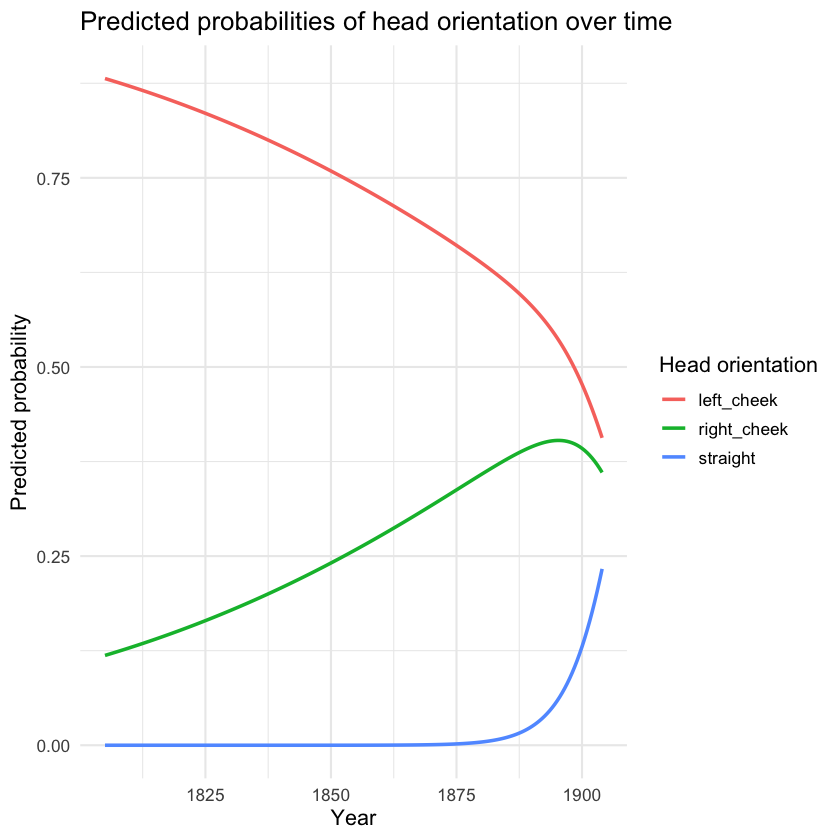

In [40]:
# Classify ukiyo-e head orientations (+/-7.5 degrees threshold) and run multinomial logistic regression to test for left-cheek bias across the Edo period.

# ==========================================
# 1. DATA PREPARATION
# ==========================================

dat <- ukiyo %>% filter(headPitch<90,headPitch>-90,confidence>.800) %>%
  mutate(
    headdirect = case_when(
      headYaw >  7.5 ~ "left_cheek",
      headYaw < -7.5 ~ "right_cheek",
      TRUE           ~ "straight"
    ),
    headdirect = factor(headdirect, levels = c("left_cheek","right_cheek","straight")),
    date_sc = scale(year)[,1]
  ) %>%
  filter(!is.na(headdirect), !is.na(date_sc))

cat("Sample size:", nrow(dat), "\n\n")
cat("Head Direction Distribution:\n")
print(table(dat$headdirect))

# ==========================================
# 2. FIT MULTINOMIAL LOGISTIC REGRESSION
# ==========================================

m_mn <- multinom(headdirect ~ date_sc, data = dat, trace = FALSE)

summary(m_mn)
broom::tidy(m_mn, conf.int = TRUE, exponentiate = TRUE)

# ==========================================
# 3. TEST TREND IN LEFT-CHEEK BIAS
# ==========================================

em_trend_right    <- emtrends(m_mn, ~ 1, var = "date_sc", mode = "latent", which = "right_cheek")
em_trend_straight <- emtrends(m_mn, ~ 1, var = "date_sc", mode = "latent", which = "straight")
em_trend_right
em_trend_straight

# ==========================================
# 4. PREDICTED PROBABILITY CURVE
# ==========================================

# BUG FIX: ukiyo-e data uses 'year', not 'date'; use dat throughout
grid <- tibble(
  date = seq(min(dat$year), max(dat$year), length.out = 200)
) %>%
  mutate(date_sc = (date - mean(dat$year, na.rm = TRUE)) / sd(dat$year, na.rm = TRUE))

emm_curve <- emmeans(m_mn, ~ headdirect | date_sc, at = list(date_sc = grid$date_sc), type = "response")
plotdf <- as.data.frame(emm_curve) %>%
  mutate(date = grid$date[match(date_sc, grid$date_sc)])
ggplot(plotdf, aes(x = date, y = prob, color = headdirect)) +
  geom_line(size = 1) +
  labs(x = "Year", y = "Predicted probability", color = "Head orientation",
       title = "Predicted probabilities of head orientation over time") +
  theme_minimal(base_size = 13)

# ==========================================
# 5. EXTRACT RESULTS
# ==========================================

coef_mn    <- coef(m_mn)
se_mn      <- summary(m_mn)$standard.errors
z_values   <- coef_mn / se_mn
p_values   <- 2 * (1 - pnorm(abs(z_values)))
or_mn      <- exp(coef_mn)
or_ci_lower <- exp(coef_mn - 1.96 * se_mn)
or_ci_upper <- exp(coef_mn + 1.96 * se_mn)

# ==========================================
# 6. COMPILE RESULTS TABLE
# ==========================================

results_table <- data.frame(
  Outcome = c(
    "Right Cheek vs Left Cheek", "Right Cheek vs Left Cheek",
    "Straight vs Left Cheek",    "Straight vs Left Cheek"
  ),
  Predictor = c(
    "Intercept", "Year (standardized)",
    "Intercept", "Year (standardized)"
  ),
  Coefficient = c(
    round(coef_mn[1, 1], 3), round(coef_mn[1, 2], 3),
    round(coef_mn[2, 1], 3), round(coef_mn[2, 2], 3)
  ),
  SE = c(
    round(se_mn[1, 1], 3), round(se_mn[1, 2], 3),
    round(se_mn[2, 1], 3), round(se_mn[2, 2], 3)
  ),
  z = c(
    round(z_values[1, 1], 2), round(z_values[1, 2], 2),
    round(z_values[2, 1], 2), round(z_values[2, 2], 2)
  ),
  p_value = c(
    ifelse(p_values[1, 1] < 0.001, "<.001", round(p_values[1, 1], 3)),
    ifelse(p_values[1, 2] < 0.001, "<.001", round(p_values[1, 2], 3)),
    ifelse(p_values[2, 1] < 0.001, "<.001", round(p_values[2, 1], 3)),
    ifelse(p_values[2, 2] < 0.001, "<.001", round(p_values[2, 2], 3))
  ),
  OR = c(
    round(or_mn[1, 1], 3), round(or_mn[1, 2], 3),
    round(or_mn[2, 1], 3), round(or_mn[2, 2], 3)
  ),
  CI_95 = c(
    paste0("[", round(or_ci_lower[1, 1], 3), ", ", round(or_ci_upper[1, 1], 3), "]"),
    paste0("[", round(or_ci_lower[1, 2], 3), ", ", round(or_ci_upper[1, 2], 3), "]"),
    paste0("[", round(or_ci_lower[2, 1], 3), ", ", round(or_ci_upper[2, 1], 3), "]"),
    paste0("[", round(or_ci_lower[2, 2], 3), ", ", round(or_ci_upper[2, 2], 3), "]")
  )
)

cat("\n===== RESULTS TABLE =====\n")
print(results_table)

# ==========================================
# 7. MODEL FIT STATISTICS
# ==========================================

predicted_class  <- predict(m_mn, type = "class")
confusion_matrix <- table(Observed = dat$headdirect, Predicted = predicted_class)
accuracy         <- sum(diag(confusion_matrix)) / sum(confusion_matrix)

model_fit <- data.frame(
  Statistic = c("N observations", "N parameters", "Log-likelihood", "AIC", "BIC"),
  Value = c(
    nrow(dat),
    length(coef(m_mn)),
    round(logLik(m_mn)[1], 2),
    round(AIC(m_mn), 2),
    round(BIC(m_mn), 2)
  )
)

cat("\n===== MODEL FIT =====\n")
print(model_fit)
cat("\n===== CONFUSION MATRIX =====\n")
print(confusion_matrix)
cat("\nOverall accuracy:", round(accuracy, 3), "\n")

# Sample distribution
sample_char <- dat %>%
  group_by(headdirect) %>%
  summarise(n = n(), .groups = "drop") %>%
  mutate(
    Percentage = round(n / nrow(dat) * 100, 1),
    headdirect = case_when(
      headdirect == "left_cheek"  ~ "Left Cheek",
      headdirect == "right_cheek" ~ "Right Cheek",
      headdirect == "straight"    ~ "Straight"
    )
  ) %>%
  rename("Head Direction" = headdirect, "N" = n, "%" = Percentage)

# ==========================================
# 8. LATEX TABLES
# ==========================================

coef_table <- results_table %>% select(Outcome, Predictor, Coefficient, SE, z, p_value)
or_table   <- results_table %>% select(Outcome, Predictor, OR, CI_95)

# Write coefficient table to .tex file
print(
  xtable(coef_table,
         caption = "Multinomial Logistic Regression: Log-Odds Coefficients (Ukiyo-e)",
         label   = "tab:ukiyo_mn_coef",
         digits  = 3),
  include.rownames       = FALSE,
  booktabs               = TRUE,
  sanitize.text.function = identity,
  file                   = "result12_fixed_effects_ukiyo_left_cheek.tex"
)

# Append OR table to same .tex file
print(
  xtable(or_table,
         caption = "Multinomial Logistic Regression: Odds Ratios with 95\\% CI (Ukiyo-e)",
         label   = "tab:ukiyo_mn_or",
         digits  = 3),
  include.rownames       = FALSE,
  booktabs               = TRUE,
  sanitize.text.function = identity,
  file                   = "result12_fixed_effects_ukiyo_left_cheek.tex",
  append                 = TRUE
)

# Inline print: coefficient table
cat("\n===== LATEX: Coefficient Table =====\n")
print(
  xtable(coef_table,
         caption = "Multinomial Logistic Regression: Log-Odds Coefficients (Ukiyo-e)",
         digits  = 3),
  include.rownames       = FALSE,
  booktabs               = TRUE,
  sanitize.text.function = identity
)

# Inline print: OR table
cat("\n===== LATEX: Odds Ratio Table =====\n")
print(
  xtable(or_table,
         caption = "Multinomial Logistic Regression: Odds Ratios with 95\\% CI (Ukiyo-e)",
         digits  = 3),
  include.rownames       = FALSE,
  booktabs               = TRUE,
  sanitize.text.function = identity
)

# Inline print: model fit
cat("\n===== LATEX: Model Fit Table =====\n")
print(
  xtable(model_fit,
         caption = "Model Fit Statistics: Multinomial Logistic Regression (Ukiyo-e)",
         digits  = 2),
  include.rownames       = FALSE,
  booktabs               = TRUE
)

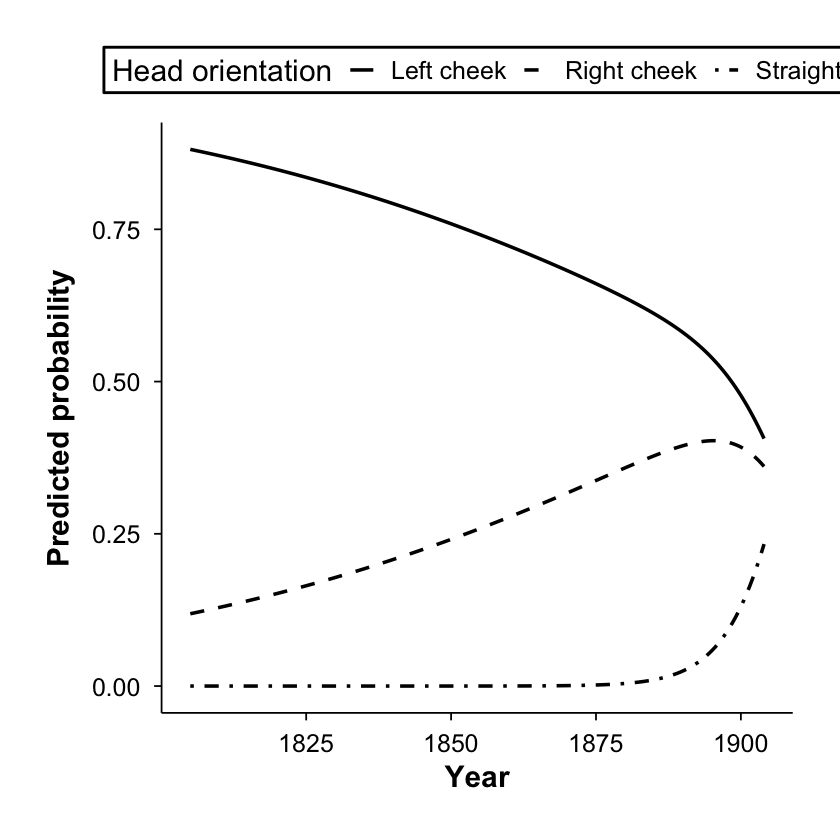

In [41]:
# Plot predicted probabilities of head orientations over time in ukiyo-e prints.
(p <- ggplot(plotdf, aes(x = date, y = prob, linetype = headdirect)) +
  geom_line(size = 1, colour = "black") +
  scale_linetype_manual(
    values = c("solid", "dashed", "dotdash"),
    labels = c("Left cheek", "Right cheek", "Straight")
  ) +
  labs(
    x = "Year",
    y = "Predicted probability",
    linetype = "Head orientation",
    ))
# ggsave('Cheek_Ukiyo.png',p)

## LOESS

,filename,Condition,headYaw,headPitch,gazeYaw,gazePitch,confidence,emotion_index,gaze_yaw,gaze_pitch,⋯,Success,ERROR,Date,TF,log_hits,log_fame,gaze_cen,BIRTH_YEAR,AGE_AT_WORK,decade_bin
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,⋯,<chr>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,00portr1,Renaissance,60.103273,36.497412,-40.1643414,32.887777,0.875,0,-0.19717234,0.153603986,⋯,ok,NA,2025-08-28T08:44:01Z,1401,8.6324842,NA,40.1643414,1406,34,1400 - 1449
2,0149burg,Renaissance,21.829692,13.349917,-15.8709309,18.162762,0.975,0,-0.07796484,0.229188904,⋯,ok,NA,2025-08-28T08:44:02Z,1451,3.6635616,1.098612,15.8709309,NA,NA,1450 - 1499
3,01altovi,Renaissance,-26.184171,21.944284,13.2353251,24.408002,0.975,5,-0.13617858,0.126954943,⋯,ok,NA,2025-08-28T08:44:03Z,1501,6.1333980,1.791759,13.2353251,1483,29,1500 - 1549
4,01amerba,Renaissance,35.580679,18.162762,-28.2468193,23.605861,0.875,6,-0.14863876,0.108155325,⋯,ok,NA,2025-08-28T08:44:04Z,1501,3.5553481,2.397895,28.2468193,1497,22,1500 - 1549
5,01berck,Renaissance,7.849522,32.085637,-5.6149864,31.856453,0.925,7,-0.22806630,-0.027669542,⋯,ok,NA,2025-08-28T08:44:05Z,1501,4.4543473,NA,5.6149864,1497,39,1500 - 1549
6,01bluesl,Renaissance,-36.898482,16.844959,26.2987628,24.236115,0.975,0,-0.11545724,0.007008671,⋯,ok,NA,2025-08-28T08:44:06Z,1501,3.5553481,NA,26.2987628,1490,20,1500 - 1549
7,01castig,Renaissance,16.157410,20.569185,-7.3911556,21.829692,0.925,0,-0.03491806,-0.123205572,⋯,ok,NA,2025-08-28T08:44:08Z,1501,6.5820251,3.806662,7.3911556,1483,31,1500 - 1549
8,01father,Renaissance,26.470650,26.814425,-11.1726770,31.283496,0.975,6,-0.14043608,0.089156061,⋯,ok,NA,2025-08-28T08:44:09Z,1501,3.5835189,NA,11.1726770,1471,26,1450 - 1499
9,01fillas1,Renaissance,23.319382,17.704396,-18.9649030,19.423269,0.975,0,-0.06370926,0.327154577,⋯,ok,NA,2025-08-28T08:44:10Z,1401,2.1972246,NA,18.9649030,1400,40,1400 - 1449


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


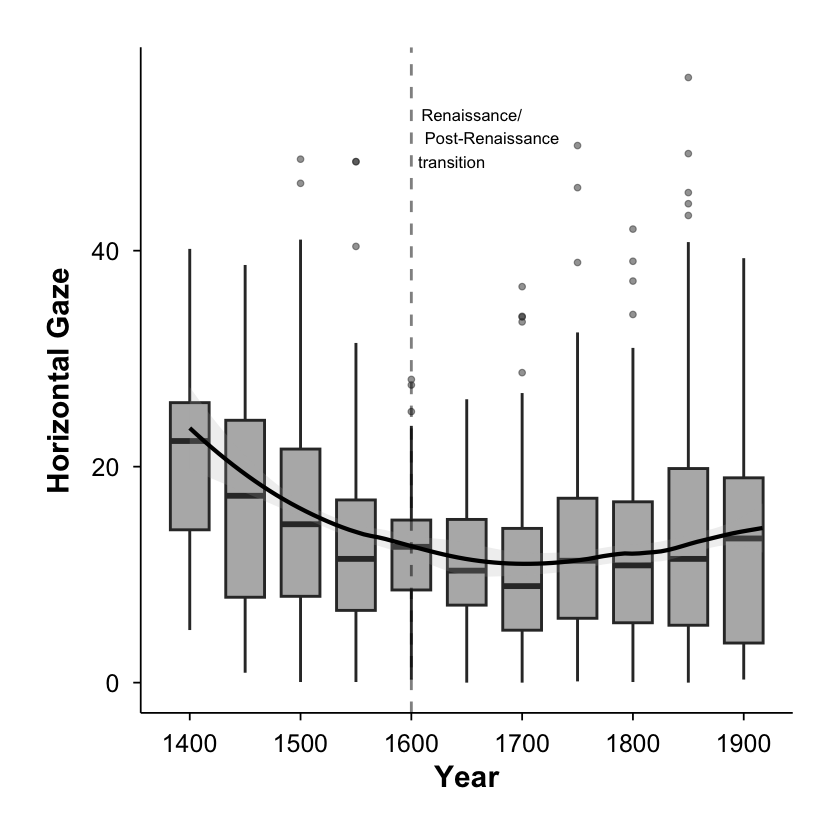

In [42]:
# Generate combined LOESS smooth of absolute gaze deviation across the full Renaissance + post-Renaissance timeline (1400–1920).
# Combined Renaissance + Post-Renaissance LOESS plot
# Filter data: both conditions, valid date range
combined_data <- metadf %>% 
  filter(Condition %in% c('Renaissance', 'Post_Renaissance'),
         SCHOOL != 'Other',
         date >= 1400, 
         date <= 1920,
         headPitch < 90, 
         headPitch > -90,
         confidence > 0.80) %>% 
  # Create 50-year bins
  mutate(decade_bin = cut(date, 
                          breaks = seq(1400, 1950, by = 50),
                          labels = paste(seq(1400, 1900, by = 50), 
                                        "-", 
                                        seq(1449, 1949, by = 50)),
                          include.lowest = TRUE))
combined_data <- combined_data %>% mutate(Condition = case_when(date < 1600 ~ 'Renaissance',
                            TRUE ~ 'Post_Renaissance'))
head(combined_data,30)
# Create LOESS + boxplot
p_loess_box <- ggplot(combined_data, aes(x = date, y = gaze_cen)) +
  
  # Boxplots for 50-year bins
  geom_boxplot(aes(x = as.numeric(decade_bin) * 50 + 1350,  # center boxplot
                   fill = decade_bin),
               width = 35,  # width of boxplot (adjust as needed)
               alpha = 0.6,
               outlier.size = 1.5,
               outlier.alpha = 0.5) +
  
  # LOESS smoothing curve with confidence band
  geom_smooth(method = "loess", 
              span = 0.5,
              se = TRUE,
              color = "black", 
              fill = "gray70",
              linewidth = 1.2,
              alpha = 0.2) +
  
  # Add vertical line at Renaissance/Post-Renaissance boundary
  geom_vline(xintercept = 1600, linetype = "dashed", 
             color = "black", alpha = 0.5, linewidth = 0.8) +
  
  # Add annotation
  annotate("text", x = 1600, y = max(combined_data$gaze_cen, na.rm = TRUE) * 0.9,
           label = "Renaissance/\nPost-Renaissance\ntransition", 
           hjust = -0.1, size = 3.5, color = "black") +
  
  # Labels and scales
  labs(x = "Year", 
       y = "Horizontal Gaze",
       # title = "Temporal Dynamics of Gaze Orientation (1400-1920)",
       fill = "Period") +
  scale_x_continuous(breaks = seq(1400, 1900, 100)) +
  scale_fill_manual(values = c("Renaissance" = "#0072B2", 
                               "Post_Renaissance" = "#D55E00")) +
  
  theme_minimal(base_size = 18) + apa_theme +
  theme(legend.position = "right")

# Display plot
print(p_loess_box)

# Save plot
ggsave('Combined_Gaze_LOESS_Boxplot.png', p_loess_box, 
       width = 14, height = 8, dpi = 300, bg = "white")
